# Project Overview
* CNN X_ray Lung Classification: Normal, Pneumonia and Tuberculosis(TB)
* Build 5 custom CNN architectures using TensorFlow / Keras
* Treating Imbalance (Class_weight, Focal Loss)
* Feature Extraction :
  - Load U-Net Segmentation Model
  - (https://www.kaggle.com/datasets/farhanhaikhan/unet-lung-segmentation-weights-for-chest-x-rays/data)
  - Masked Generation Using U-Net Pretrained Model
  - Masked Data Generation Using U-Net Pretrained Model
  - Cleaning Masked Data 
* Explainable AI(XAI):
  - Grad_CAM: Gradient-weighted Class Activation Mapping
  - Grad_CAM is used for pixel Analysis
* Convolutional Block Attention Module:
  - "CBAM: Convolutional Block Attention Module" (Woo et al., ECCV 2018)
  - Formula: Feature → Channel Attention → Spatial Attention → Refined Feature
  - CBAM block: Conv → BN → ReLU → CBAM → next layer
  - (https://joonyoung-cv.github.io/assets/paper/18_eccv_cbam.pdf)
* Callbacks and Techniques:
  - EarlyStopping, ReduceRLOnPlateau and Augmentation
* Transfer Learning Using DenseNet121 Pretrained Model
* Fine Tuning For DenseNet121 Model
* Transfer Learning Using EfficientNetB0 Pretrained Model
* Fine Tuning For EfficientNetB0 Model
* Evaluate The Best Model On the Test Data
# Main Challenge
* Challenge of the project was to increase the TB recall because High TB recall is  important in medical applications because missing TB cases can be dangerous
# Main Resource
* https://ieeexplore.ieee.org/abstract/document/9224622#algorithms

## Set my seed

In [2]:
import tensorflow as tf
import random
import numpy as np
import os
SEED = 123
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-11-02 04:20:15.878897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762057216.047209      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762057216.105685      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Get chest_x-ray_dataset(Train + Val)

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(   ## get my train data
    '/kaggle/input/chest-xray-dataset/train',
    image_size=(512,512),
    batch_size=32,
    labels='inferred',
    shuffle=True,
    color_mode='rgb',
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(    ## get my val data
    '/kaggle/input/chest-xray-dataset/val',
    image_size=(512,512),
    batch_size=32,
    labels='inferred',
    shuffle=False,
    color_mode='rgb',
    label_mode="int"
)

Found 20450 files belonging to 3 classes.


I0000 00:00:1762052256.286046      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2534 files belonging to 3 classes.


## Plot some x-ray images

In [4]:
class_names = train_ds.class_names

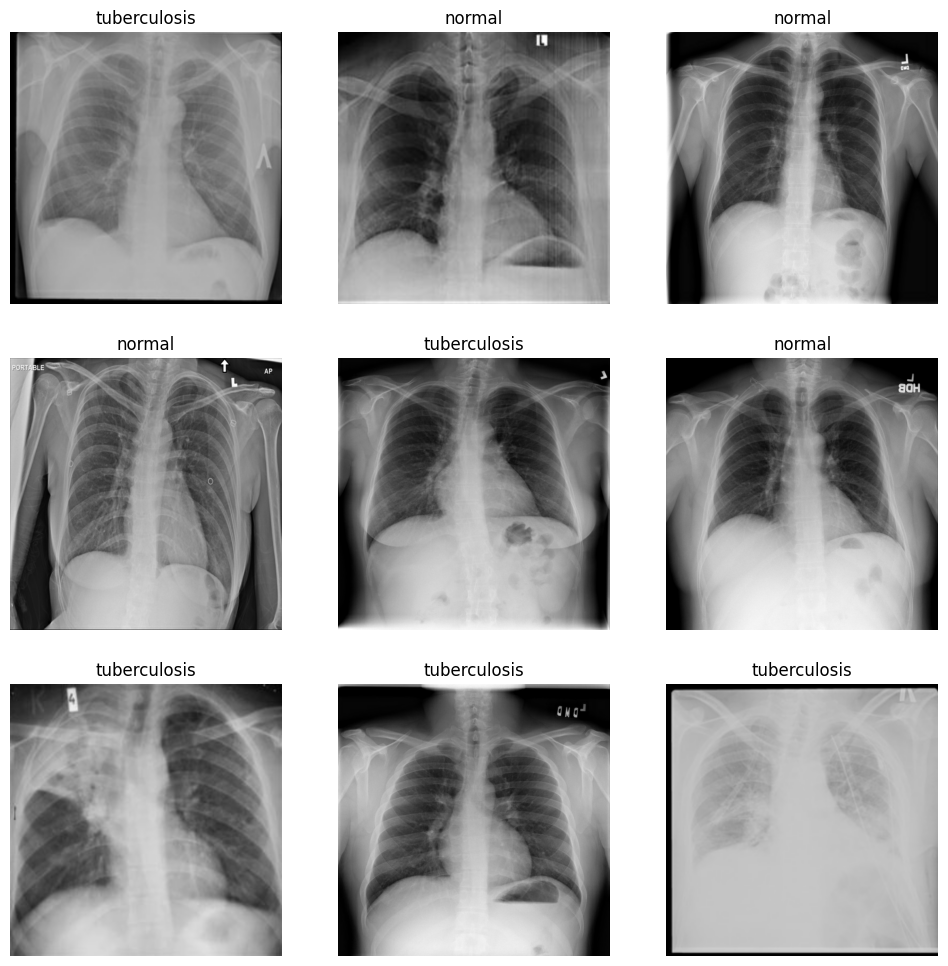

In [5]:
## Let us plot some images to see the classes
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    break



## Check the classes imbalance

In [6]:
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt

label_list = []  # Extract labels from train_ds
for _, labels in train_ds.unbatch():  #converts the batched dataset into a stream of individual samples
    # if label is int, convert it to Python int and append it to label_list
    if len(labels.shape) == 0:
        label_list.append(int(labels.numpy()))
    else:
        # if label is one hot encoded, take the index of the 1 using argmax to get the class index.
        label_list.append(int(tf.argmax(labels, axis=-1).numpy()))

# Count labels
class_counts = Counter(label_list) # Counter to count the number of samples for each class
print("Class counts:", class_counts)

Class counts: Counter({2: 8513, 0: 7263, 1: 4674})


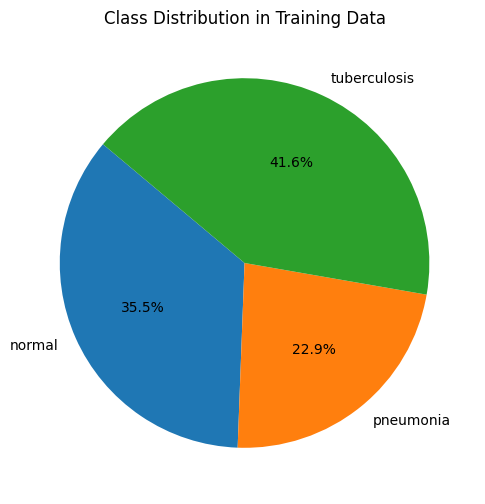

In [7]:
class_names = train_ds.class_names
counts = [class_counts[i] for i in range(len(class_names))]
## plot 
plt.figure(figsize=(6,6))
plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=140)
plt.title("Class Distribution in Training Data")
plt.show()

In [8]:
import tensorflow as tf  ## I just need to check the gpu before training
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Callbacks(Early_Stopping + ReduceLROnPlateau)

In [9]:
ReduceLrOnPlat = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor= 0.5,        # reduce LR by half
    patience= 5 ,         # after 5 stagnant epochs
    min_lr=1e-6,        # don’t go below this
    verbose=1            # Prints a message 
)


In [10]:
from tensorflow.keras import layers, models, callbacks
# Early stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', # Track validation loss to decide when to stop
    patience = 7,    # Allow 7 epochs of no improvement before stopping
    restore_best_weights=True, # After stopping, revert the model to the weights with the best val_loss
    verbose=1  #Prints a message 
)

## Metrics

In [11]:
import matplotlib.pyplot as plt

def plot_training_history(history, figsize=(12,5)):
    plt.figure(figsize=figsize)
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.show()


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate(model, val_ds, class_names):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0) #gives softmax probabilities.
        y_pred.extend(np.argmax(preds, axis=1))  #picks the class with the highest probability.
        
        if len(labels.shape) > 1 and labels.shape[-1] > 1: #convert to class indices using argmax
            y_true.extend(np.argmax(labels.numpy(), axis=1))
        else:
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


## Treating Imbalance through class weight

In [13]:
# Compute class weights
# Formula : total samples / (number of classes * samples in class x)
total = sum(class_counts.values())
class_weights = {     # Compute class weights inversely proportional to class frequency
    int(cls): total / (len(class_counts) * count)
    for cls, count in class_counts.items() #Loops through class names & get the weights
}
# Print with class names
print("\nClass Weights by Class Name:")
for i, name in enumerate(class_names):
    weight = class_weights.get(i, 0)
    print(f"{name:<15}: {weight:.4f}")  



Class Weights by Class Name:
normal         : 0.9385
pneumonia      : 1.4584
tuberculosis   : 0.8007


## CNN_1 Model Architecture 

In [38]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Input layer
img_input_ = Input(shape=(512, 512, 3))  
input_ = Resizing(224, 224)(img_input_)
input_ = BatchNormalization()(input_)

# Convolution Layer 1
hidden = Conv2D(32, kernel_size=3, padding='same', kernel_initializer='he_normal')(input_)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = Conv2D(32, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)

# Convolution Layer 2
hidden = Conv2D(64, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = Conv2D(64, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)

# Convolution Layer 3
hidden = Conv2D(128, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = Conv2D(128, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = GlobalAveragePooling2D()(hidden)

# Dense Layer
hidden = Dense(128, kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
# Dropout
hidden = Dropout(0.3)(hidden)

# Output Layer
output = Dense(3, activation='softmax', kernel_initializer='glorot_normal')(hidden)

model_weight = Model(inputs=[img_input_], outputs=[output])
model_weight.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 224, 224, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 111, 111, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 54, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 52, 52, 128)    │           51

 Total params: 306,223 (1.17 MB)

 Trainable params: 305,065 (1.16 MB)

 Non-trainable params: 1,158 (4.52 KB)

In [39]:
# Compile
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate= 0.0001)

model_weight.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy'
, metrics=['accuracy'])

In [40]:
# Train the model
history = model_weight.fit(
    train_ds,
    validation_data=val_ds,
    epochs = 20,
    callbacks = [early_stop, ReduceLrOnPlat],
    class_weight = class_weights  
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_88']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


640/640 ━━━━━━━━━━━━━━━━━━━━ 122s 163ms/step - accuracy: 0.6495 - loss: 0.7218 - val_accuracy: 0.7419 - val_loss: 0.5726 - learning_rate: 1.0000e-04
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.7501 - loss: 0.4839 - val_accuracy: 0.7569 - val_loss: 0.5060 - learning_rate: 1.0000e-04
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.7576 - loss: 0.4451 - val_accuracy: 0.7616 - val_loss: 0.5129 - learning_rate: 1.0000e-04
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.7588 - loss: 0.4315 - val_accuracy: 0.7557 - val_loss: 0.4753 - learning_rate: 1.0000e-04
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.7638 - loss: 0.4198 - val_accuracy: 0.7510 - val_loss: 0.5709 - learning_rate: 1.0000e-04
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.7669 - loss: 0.4113 - val_accuracy: 0.6385 - val_loss: 1.0668 - learning_rate: 1.0000e-04
Epoch 7/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step -

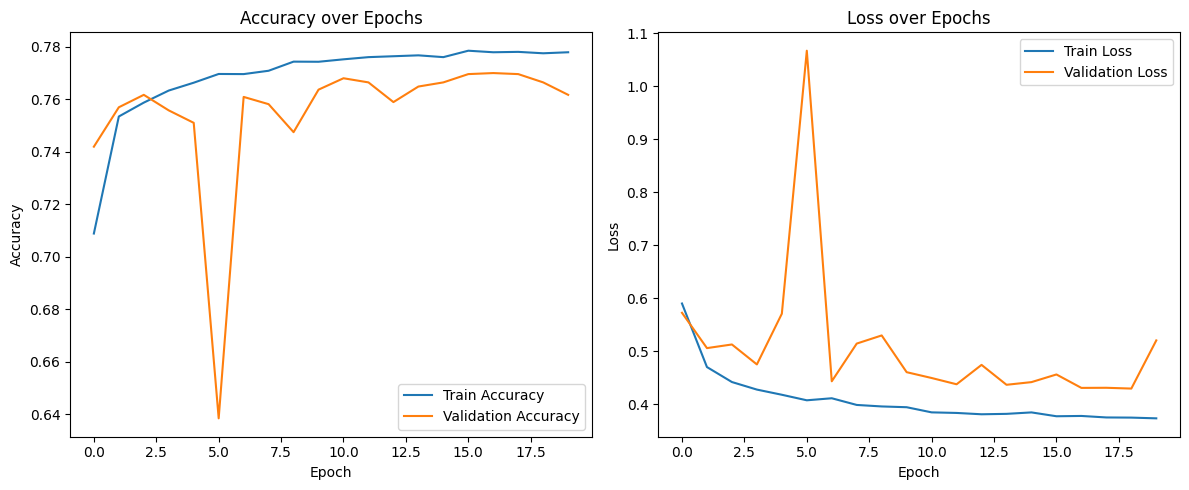

In [44]:
plot_training_history(history)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_88']
Received: inputs=Tensor(shape=(32, 512, 512, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_88']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


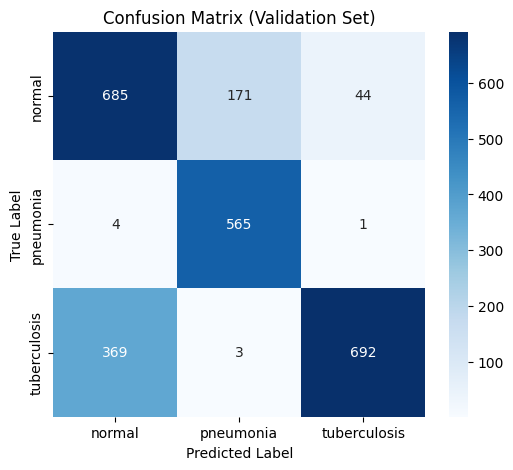


Classification Report:

              precision    recall  f1-score   support

      normal      0.647     0.761     0.700       900
   pneumonia      0.765     0.991     0.863       570
tuberculosis      0.939     0.650     0.768      1064

    accuracy                          0.766      2534
   macro avg      0.784     0.801     0.777      2534
weighted avg      0.796     0.766     0.765      2534



In [45]:
evaluate(model_weight, val_ds, class_names)

 I need to increase the TB Recall, as my model still confuses between the TB and Normal

## Apply GRAD_CAM

A colored heatmap over X-ray showing where CNN looks

In [56]:
!pip install tf-keras-vis

In [57]:
# Import Libraries
import tensorflow as tf
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

In [58]:
import tensorflow as tf

class_names = val_ds.class_names
normal_imgs = []
tb_imgs = []

# Loop through validation dataset and collect 10 of each class
for img, label in val_ds.unbatch():
    lbl = int(label.numpy())
    if lbl == class_names.index('normal') and len(normal_imgs) < 10:
        normal_imgs.append(img)
    elif lbl == class_names.index('tuberculosis') and len(tb_imgs) < 10:
        tb_imgs.append(img)
    if len(normal_imgs) == 10 and len(tb_imgs) == 10:
        break

print(f" Found {len(normal_imgs)} Normal and {len(tb_imgs)} Tuberculosis images")

 Found 10 Normal and 10 Tuberculosis images


In [55]:
# Convert lists to tensors
normal_img_array = tf.stack(normal_imgs)
tb_img_array = tf.stack(tb_imgs)

# Combine both sets into one tensor
images = tf.concat([normal_img_array, tb_img_array], axis=0)

print(" Final tensor shape:", images.shape)

 Final tensor shape: (20, 512, 512, 3)


In [50]:
modifier = ReplaceToLinear()

# Create Grad-CAM object
gradcam = Gradcam(model_weight,
                  model_modifier = modifier,
                  clone=True)

In [51]:
# You can check layer names using:
# [layer.name for layer in model.layers if 'conv' in layer.name]
last_conv_layer_name = [layer.name for layer in model_weight.layers if 'conv' in layer.name][-1]
print(f" Using last conv layer: {last_conv_layer_name}")

 Using last conv layer: conv2d_23


In [52]:
import matplotlib.pyplot as plt
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
import tensorflow as tf

# --- Generate Grad-CAM for all 20 images (10 normal + 10 TB) ---
cams = []
pred_labels = []

for i, img in enumerate(images):
    img_batch = tf.expand_dims(img, axis=0)
    preds = model_weight.predict(img_batch, verbose=0)
    pred_class = tf.argmax(preds[0]).numpy()
    pred_labels.append(class_names[pred_class])

    score = CategoricalScore([pred_class])
    cam = gradcam(score, img_batch, penultimate_layer=last_conv_layer_name)
    cams.append(cam[0])

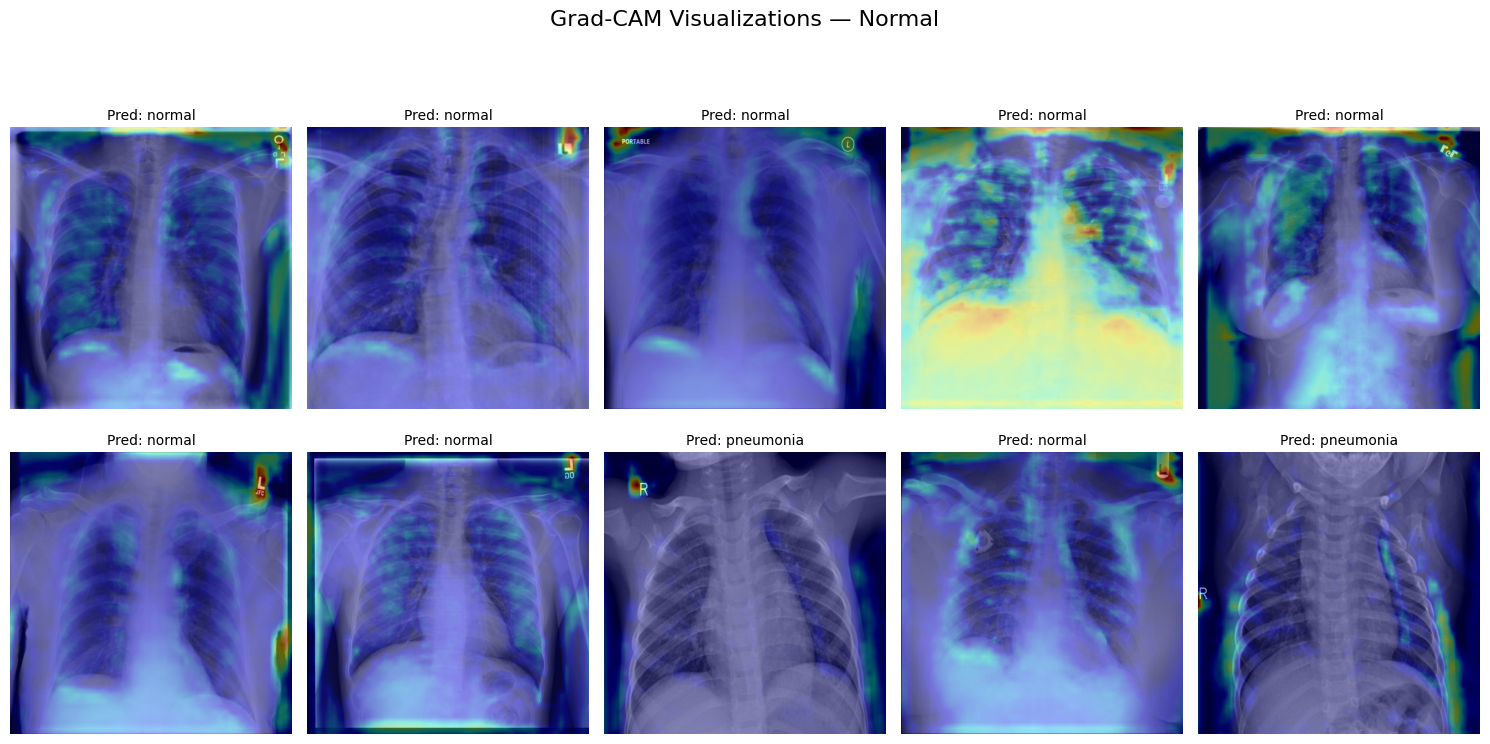

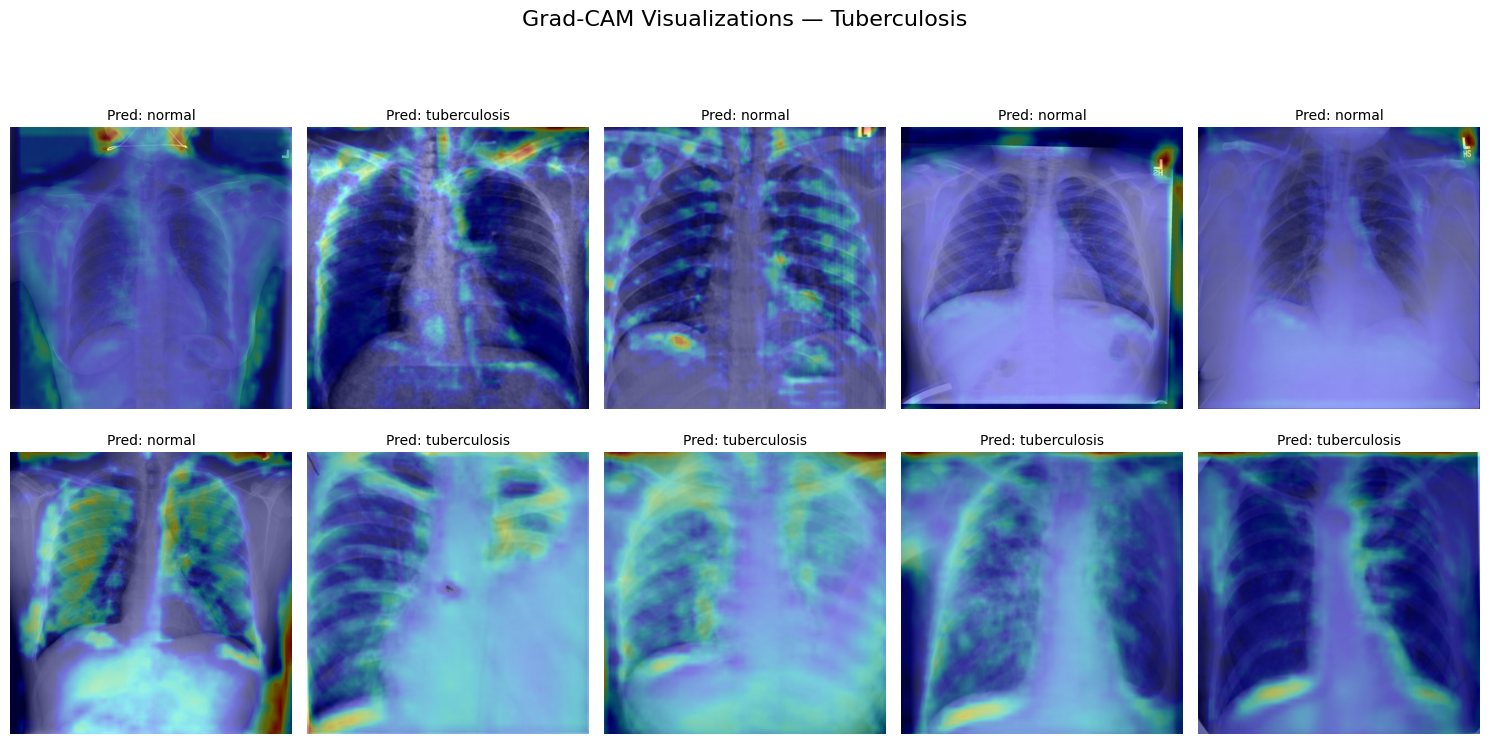

In [53]:
# --- Plot Grad-CAM results in grids ---
def plot_grid(imgs, cams, labels, class_title):
    plt.figure(figsize=(15, 8))
    plt.suptitle(f"Grad-CAM Visualizations — {class_title}", fontsize=16)

    for i in range(len(imgs)):
        plt.subplot(2, 5, i + 1)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.imshow(cams[i], cmap='jet', alpha=0.4)
        plt.title(f"Pred: {labels[i]}", fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Split back into normal and TB groups
plot_grid(normal_imgs, cams[:10], pred_labels[:10], "Normal")
plot_grid(tb_imgs, cams[10:], pred_labels[10:], "Tuberculosis")


## Load U-Net for image segmentation

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_small(input_size=(512, 512, 1)):  # change 3 to 1
    inputs = layers.Input(input_size)

    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)

    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c9)
    model = models.Model(inputs, outputs)
    return model


# Load model
seg_model = unet_small()
seg_model.load_weights("/kaggle/input/seg-model/tensorflow2/default/1/cxr_reg_weights.best.hdf5")
print("Lung segmentation U-Net loaded successfully!")


Lung segmentation U-Net loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


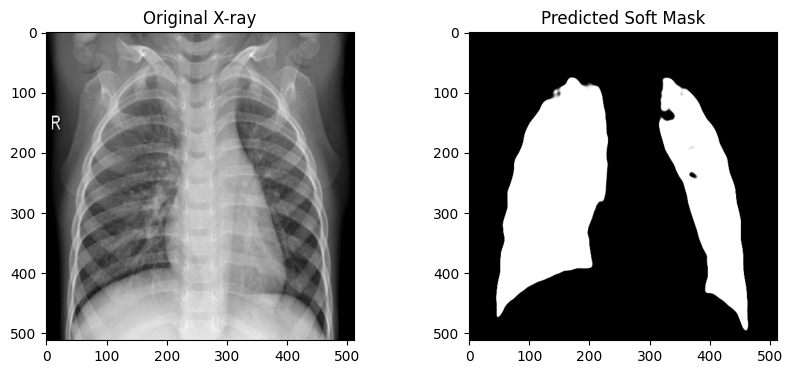

In [55]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load one grayscale image (since model expects 1 channel)
img_path = '/kaggle/input/chest-xray-dataset/train/normal/normal-1011.jpg'
img = tf.keras.utils.load_img(img_path, color_mode='grayscale', target_size=(512,512))
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_input = tf.expand_dims(img_array, axis=0)  # shape (1,224,224,1)

# Predict mask
pred_mask = seg_model.predict(img_input)[0]

# Plot image and soft mask
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_array[:,:,0], cmap='gray')
plt.title("Original X-ray")

plt.subplot(1,2,2)
plt.imshow(pred_mask[:,:,0], cmap='gray')
plt.title("Predicted Soft Mask")
plt.show()


## Create mask dataset using U-Net

In [52]:
# import tensorflow as tf
# import numpy as np
# from PIL import Image
# import os
# import zipfile
# import io
# from tqdm import tqdm

# def generate_mask(img_path):
#     img = tf.io.read_file(img_path)
#     img = tf.image.decode_jpeg(img, channels=1)
#     img_resized = tf.image.resize(img, (512, 512))
#     img_resized = tf.cast(img_resized, tf.float32) / 255.0
#     img_input = tf.expand_dims(img_resized, 0)
    
#     # Predict soft mask
#     mask = seg_model.predict(img_input, verbose=0)[0]
#     mask = tf.squeeze(mask, axis=-1)
#     mask = tf.clip_by_value(mask, 0, 1)
#     return mask, img  # return original image too

# input_dir = "/kaggle/input/chest-xray-dataset/train"
# output_dir = "/kaggle/working/masks"
# os.makedirs(output_dir, exist_ok=True)

# zip_path = "/kaggle/working/soft_masked_images.zip"

# count = 0
# batch_size = 500

# with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
#     for class_name in os.listdir(input_dir):
#         class_dir = os.path.join(input_dir, class_name)
#         save_dir = os.path.join(output_dir, class_name)
#         os.makedirs(save_dir, exist_ok=True)

#         files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

#         for file in tqdm(files, desc=f"Processing {class_name}"):
#             img_path = os.path.join(class_dir, file)
#             pred_mask, orig_img = generate_mask(img_path)

#             # Resize mask to original image size
#             orig_shape = tf.shape(orig_img)[:2]
#             pred_mask_orig = tf.image.resize(tf.expand_dims(pred_mask, -1), orig_shape, method='bilinear')
#             pred_mask_orig = tf.squeeze(pred_mask_orig, axis=-1).numpy()

#             # --- Apply soft mask (fix broadcasting) ---
#             img_array = tf.cast(orig_img, tf.float32).numpy() / 255.0
#             pred_mask_orig = np.expand_dims(pred_mask_orig, axis=-1)  # match channels
#             soft_masked_img = img_array * pred_mask_orig  # element-wise multiplication

#             # Convert to 8-bit for saving
#             save_img = (soft_masked_img * 255).astype(np.uint8)
#             save_pil = Image.fromarray(save_img[:, :, 0], mode='L')

#             # Save to zip
#             buf = io.BytesIO()
#             save_pil.save(buf, format='PNG')
#             buf.seek(0)
#             zipf.writestr(os.path.join(class_name, os.path.splitext(file)[0] + "_soft.png"), buf.read())

#             count += 1
#             if count % batch_size == 0:
#                 print(f"Processed {count} images. Saving progress...")
#                 tf.keras.backend.clear_session()

# print(f"All soft-masked images saved successfully in: {zip_path} ")


Processing pneumonia:   0%|          | 0/4674 [00:00<?, ?it/s]/tmp/ipykernel_37/222876799.py:58: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  save_pil = Image.fromarray(save_img[:, :, 0], mode='L')
Processing pneumonia:  11%|█         | 500/4674 [01:21<19:31,  3.56it/s]

Processed 500 images. Saving progress...


Processing pneumonia:  21%|██▏       | 1000/4674 [02:45<16:35,  3.69it/s]

Processed 1000 images. Saving progress...


Processing pneumonia:  32%|███▏      | 1500/4674 [04:08<16:03,  3.29it/s]

...

Processed 19000 images. Saving progress...


Processing normal:  94%|█████████▍| 6814/7263 [16:29<01:56,  3.85it/s]

Processed 20000 images. Saving progress...


Processing normal: 100%|██████████| 7263/7263 [17:35<00:00,  6.88it/s]

All soft-masked images saved successfully in: /kaggle/working/soft_masked_images.zip ✅


## Plot some images to see the performance of U-Net Masks

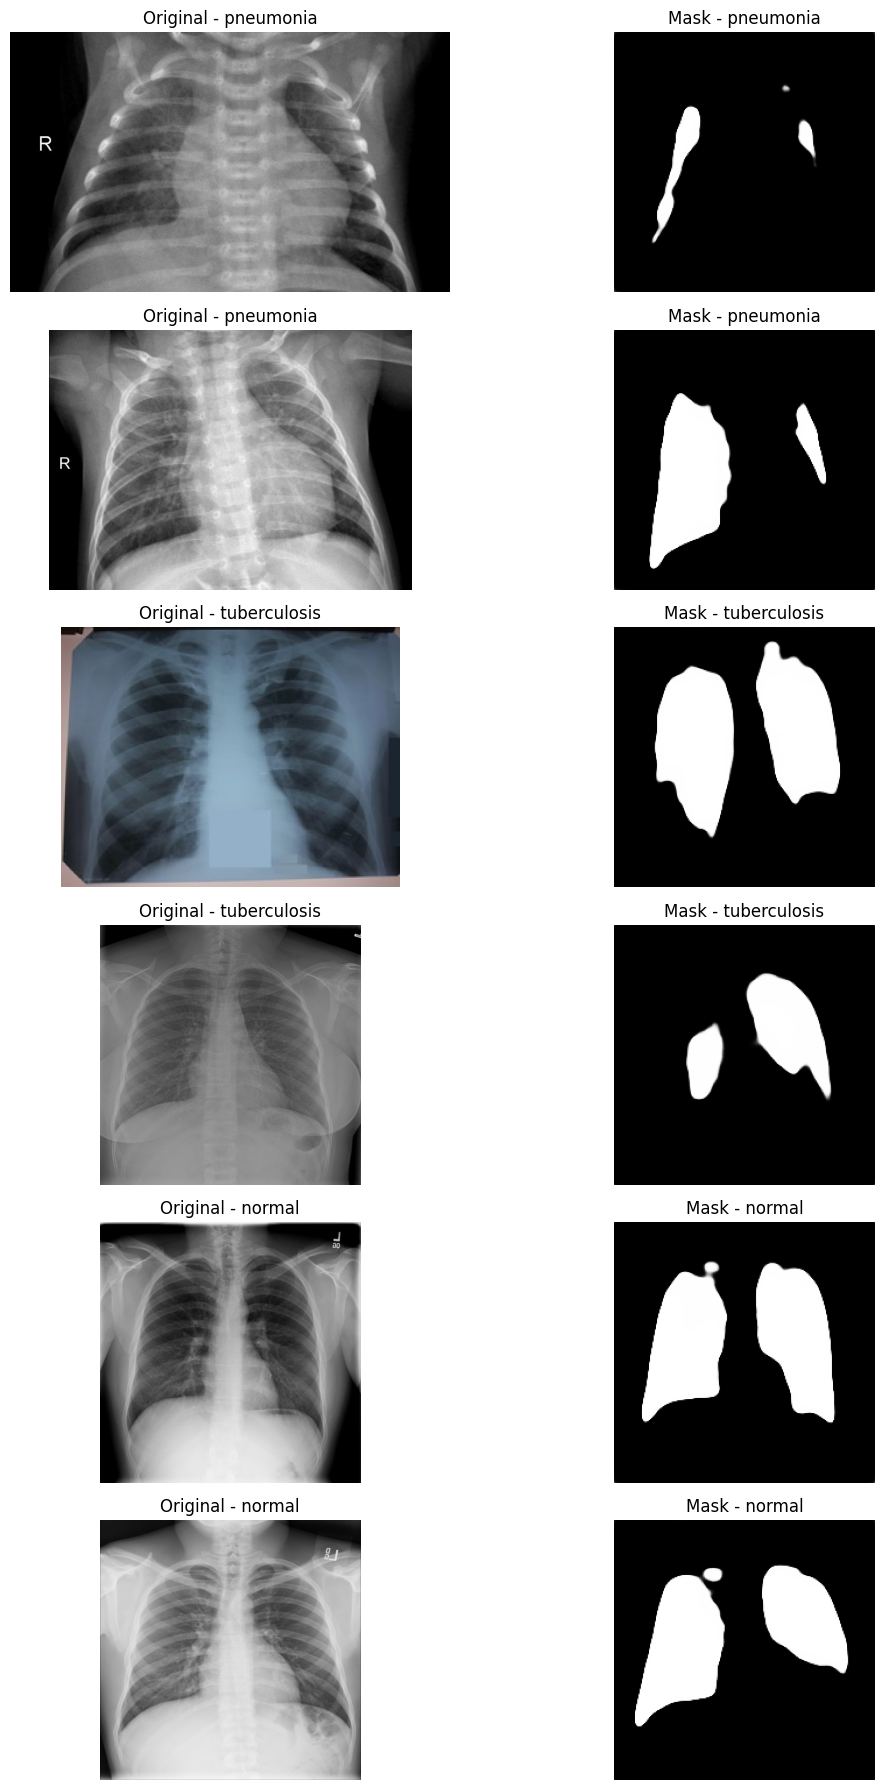

In [58]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Directories
image_dir = "/kaggle/input/chest-xray-dataset/train"
mask_dir = "/kaggle/input/lung-mask-data"

# get all class names
classes = os.listdir(image_dir)
samples = []

# collect random samples from each class (2 per class for example)
for cls in classes:
    img_files = [f for f in os.listdir(os.path.join(image_dir, cls)) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if not img_files:
        continue
    for _ in range(min(2, len(img_files))):  # pick up to 2 per class
        samples.append((cls, random.choice(img_files)))

# plot
plt.figure(figsize=(12, len(samples)*3))
for i, (cls, file_name) in enumerate(samples):
    img_path = os.path.join(image_dir, cls, file_name)
    mask_path = os.path.join(mask_dir, cls, file_name.replace('.jpg', '_mask.png').replace('.jpeg', '_mask.png'))

    if not os.path.exists(mask_path):
        continue

    # read images
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # show original
    plt.subplot(len(samples), 2, 2*i + 1)
    plt.imshow(img)
    plt.title(f"Original - {cls}")
    plt.axis("off")

    # show mask
    plt.subplot(len(samples), 2, 2*i + 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask - {cls}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Create masked dataset --> Multiply (Mask × Image)
### Keep same image size, just hide irrelevant pixels

In [57]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image
import gc

# Paths
original_dir = "/kaggle/input/chest-xray-dataset/train"
mask_dir = "/kaggle/working/masks"
output_dir = "/kaggle/working/masked_images"
os.makedirs(output_dir, exist_ok=True)

# Function to apply mask without losing info
def apply_mask_keep_info(image_path, mask_path, save_path_npy, save_path_png=None):
    try:
        # Load original image (keep original size)
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=1)
        img = tf.cast(img, tf.float32) / 255.0  # float 0-1

        # Load mask (keep original size)
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.cast(mask, tf.float32) / 255.0  # float 0-1

        # Apply soft mask
        masked = img * mask

        # Save soft-masked array as .npy
        np.save(save_path_npy, masked.numpy())

        # Optional: save visualization as PNG
        if save_path_png:
            save_img = (masked.numpy() * 255).astype(np.uint8).squeeze()
            Image.fromarray(save_img, mode='L').save(save_path_png)

    except Exception as e:
        print(f"Skipping {image_path}: {e}")

# -----------------------
# Batch processing
# -----------------------
batch_size = 64

for class_name in os.listdir(original_dir):
    class_path = os.path.join(original_dir, class_name)
    mask_class_path = os.path.join(mask_dir, class_name)
    save_class_path = os.path.join(output_dir, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    total = len(files)

    for i in range(0, total, batch_size):
        batch_files = files[i:i + batch_size]
        print(f"Processing {class_name}: batch {i//batch_size + 1}/{(total//batch_size)+1}")

        for file in batch_files:
            img_path = os.path.join(class_path, file)
            mask_path = os.path.join(mask_class_path, file.replace('.jpg', '_mask.png'))
            save_path_npy = os.path.join(save_class_path, file.replace('.jpg', '_soft.npy'))
            save_path_png = os.path.join(save_class_path, file.replace('.jpg', '_soft.png'))

            if os.path.exists(mask_path):
                apply_mask_keep_info(img_path, mask_path, save_path_npy, save_path_png)

        # Clean up memory
        gc.collect()
        tf.keras.backend.clear_session()

print("All soft-masked images saved successfully!")


Processing pneumonia: batch 1/74
Skipping /kaggle/input/chest-xray-dataset/train/pneumonia/pneumonia-4672.jpg: {{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:Mul] name: 
Skipping /kaggle/input/chest-xray-dataset/train/pneumonia/pneumonia-1175.jpg: {{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:Mul] name: 
Skipping /kaggle/input/chest-xray-dataset/train/pneumonia/pneumonia-2848.jpg: {{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:Mul] name: 
Skipping /kaggle/input/chest-xray-dataset/train/pneumonia/pneumonia-1538.jpg: {{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:Mul] name: 
Skipping /kaggle/input/chest-xray-dataset/train/pneumonia/pneumonia-3914.jpg: {{function_node __wrapped__Mul_device_/job:localhost/

## Save it in a zipped file

In [107]:
# import shutil

# # Path to your masked images folder
# masked_folder = "/kaggle/working/masked_images"
# zip_filename = "/kaggle/working/masked_images.zip"

# # Create zip
# shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', masked_folder)

# print("Masked dataset zipped successfully!")
# print(f"File saved as: {zip_filename}")


## Apply it on val data 

In [2]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import zipfile
import io
from tqdm import tqdm

def generate_mask(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=1)
    img_resized = tf.image.resize(img, (512, 512))
    img_resized = tf.cast(img_resized, tf.float32) / 255.0
    img_input = tf.expand_dims(img_resized, 0)
    
    # Predict soft mask
    mask = seg_model.predict(img_input, verbose=0)[0]
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.clip_by_value(mask, 0, 1)
    return mask, img  # return original image too

input_dir = "/kaggle/input/chest-xray-dataset/val"
output_dir = "/kaggle/working/masks_val"
os.makedirs(output_dir, exist_ok=True)

zip_path = "/kaggle/working/soft_masked_images_val.zip"

count = 0
batch_size = 500

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for class_name in os.listdir(input_dir):
        class_dir = os.path.join(input_dir, class_name)
        save_dir = os.path.join(output_dir, class_name)
        os.makedirs(save_dir, exist_ok=True)

        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for file in tqdm(files, desc=f"Processing {class_name}"):
            img_path = os.path.join(class_dir, file)
            pred_mask, orig_img = generate_mask(img_path)

            # Resize mask to original image size
            orig_shape = tf.shape(orig_img)[:2]
            pred_mask_orig = tf.image.resize(tf.expand_dims(pred_mask, -1), orig_shape, method='bilinear')
            pred_mask_orig = tf.squeeze(pred_mask_orig, axis=-1).numpy()

            # --- Apply soft mask (fix broadcasting) ---
            img_array = tf.cast(orig_img, tf.float32).numpy() / 255.0
            pred_mask_orig = np.expand_dims(pred_mask_orig, axis=-1)  # match channels
            soft_masked_img = img_array * pred_mask_orig  # element-wise multiplication

            # Convert to 8-bit for saving
            save_img = (soft_masked_img * 255).astype(np.uint8)
            save_pil = Image.fromarray(save_img[:, :, 0], mode='L')

            # Save to zip
            buf = io.BytesIO()
            save_pil.save(buf, format='PNG')
            buf.seek(0)
            zipf.writestr(os.path.join(class_name, os.path.splitext(file)[0] + "_soft.png"), buf.read())

            count += 1
            if count % batch_size == 0:
                print(f"Processed {count} images. Saving progress...")
                tf.keras.backend.clear_session()

print(f"All soft-masked images saved successfully in: {zip_path} ")


Processing pneumonia:   0%|          | 0/570 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1761669607.122321      98 service.cc:148] XLA service 0x7b8060004660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761669607.122923      98 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761669607.296086      98 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1761669609.760151      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/tmp/ipykernel_37/3407928195.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  save_pil = Image.fromarray(save_img[:, :, 0], mode='L')
Processing pneumonia:  88%|████████▊ | 500/570 [01:34<00:15,  4.42it/s]

Processed 500 images. Saving progress...


Processing tuberculosis:  40%|████      | 430/1064 [00:50<01:59,  5.32it/s]

Processed 1000 images. Saving progress...


Processing tuberculosis:  87%|████████▋ | 930/1064 [01:48<00:27,  4.83it/s]

...

Processed 2000 images. Saving progress...


Processing normal:  96%|█████████▌| 866/900 [02:25<00:09,  3.53it/s]

Processed 2500 images. Saving progress...


Processing normal: 100%|██████████| 900/900 [02:30<00:00,  5.97it/s]

All soft-masked images saved successfully in: /kaggle/working/soft_masked_images_val.zip 


In [59]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image
import gc

# Paths
original_dir = "/kaggle/input/chest-xray-dataset/val"
mask_dir = "/kaggle/working/masks_val"
output_dir = "/kaggle/working/masked_images_val"
os.makedirs(output_dir, exist_ok=True)

def apply_mask_keep_info(image_path, mask_path, save_path_png=None):
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=1)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.cast(mask, tf.float32) / 255.0

        masked = img * mask

        if save_path_png:
            save_img = (masked.numpy() * 255).astype(np.uint8).squeeze()
            Image.fromarray(save_img, mode='L').save(save_path_png)
    except Exception as e:
        print(f"Skipping {image_path}: {e}")

# Process
for class_name in os.listdir(original_dir):
    class_path = os.path.join(original_dir, class_name)
    save_class_path = os.path.join(output_dir, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for file in files:
        mask_candidates = [
            file.replace('.jpg', '_mask.png'),
            file.replace('.jpeg', '_mask.png'),
            file.replace('.png', '_mask.png')
        ]
        mask_path = None
        for candidate in mask_candidates:
            test_path = os.path.join(mask_dir, candidate)
            if os.path.exists(test_path):
                mask_path = test_path
                break

        if mask_path:
            save_path_png = os.path.join(save_class_path, file.replace('.jpg', '_masked.png'))
            apply_mask_keep_info(os.path.join(class_path, file), mask_path, save_path_png)
        else:
            print(f"Mask not found for: {file}")

        gc.collect()
        tf.keras.backend.clear_session()

print("Validation masked images created successfully!")


## Check the length of the imaged masked  

In [61]:
import os

def count_images(folder):
    count = 0
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                count += 1
    return count

images_dir = "/kaggle/input/chest-xray-dataset/train"   # change if different
masks_dir = "/kaggle/input/lung-mask-data"

print("Total original images:", count_images(images_dir))
print("Total mask images:", count_images(masks_dir))


Total original images: 20450
Total mask images: 20450


## Plot some original images Vs masked images 

🩻 Random class selected: pneumonia


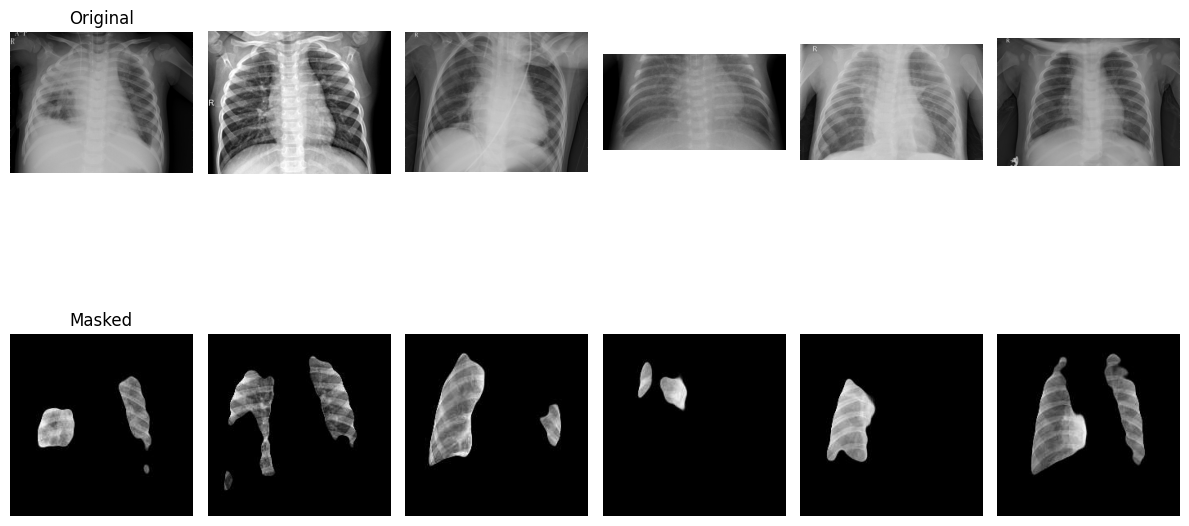

In [62]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

# Paths
original_dir = "/kaggle/input/chest-xray-dataset/train"
masked_dir = "/kaggle/input/masked-imges" 

# Choose some random class folders
classes = os.listdir(masked_dir)
random_class = random.choice(classes)
print("🩻 Random class selected:", random_class)

# List of files
masked_class_dir = os.path.join(masked_dir, random_class)
original_class_dir = os.path.join(original_dir, random_class)
masked_files = [f for f in os.listdir(masked_class_dir) if f.endswith('.png') or f.endswith('.jpg')]
sample_files = random.sample(masked_files, min(6, len(masked_files)))  # show 6 samples

# Plot
plt.figure(figsize=(12, 8))
for i, file in enumerate(sample_files):
    # Masked
    masked_img = Image.open(os.path.join(masked_class_dir, file))
    # Original
    orig_name = file.replace('_mask.png', '.jpg').replace('_masked.png', '.jpg')
    orig_path = os.path.join(original_class_dir, orig_name)
    if not os.path.exists(orig_path):
        orig_path = os.path.join(original_class_dir, orig_name.replace('.jpg', '.png'))
    original_img = Image.open(orig_path)

    plt.subplot(2, 6, i + 1)
    plt.imshow(original_img, cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Original")

    plt.subplot(2, 6, i + 7)
    plt.imshow(masked_img, cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Masked")

plt.tight_layout()
plt.show()


## Check the black images

In [63]:
import os
import cv2
import numpy as np

folder = "/kaggle/input/masked-imges"

def is_black(img_path, threshold=15, ratio=0.98):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    # Count black pixels
    black_pixels = np.sum(img < threshold)
    total_pixels = img.size
    return (black_pixels / total_pixels) > ratio

black_count = 0
non_black_count = 0

for root, _, files in os.walk(folder):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, f)
            if is_black(path):
                black_count += 1
            else:
                non_black_count += 1

print(f"Black or nearly black images: {black_count}")
print(f"Non-black images: {non_black_count}")
print(f"Total images after cleaning: {black_count + non_black_count}")


Black or nearly black images: 1388
Non-black images: 19062
Total images after cleaning: 20450


## Remove Black Images (Train + Val)

In [64]:
import os
import cv2
import numpy as np
import shutil
import zipfile

src_folder = "/kaggle/input/masked-imges"
dst_folder = "/kaggle/working/masked_cleaned"

def is_black(img_path, threshold=15, ratio=0.98):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    black_pixels = np.sum(img < threshold)
    total_pixels = img.size
    return (black_pixels / total_pixels) > ratio

if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

for root, _, files in os.walk(src_folder):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            src_path = os.path.join(root, f)
            if not is_black(src_path):
                rel_path = os.path.relpath(root, src_folder)
                dst_dir = os.path.join(dst_folder, rel_path)
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(src_path, dst_dir)

# Zip the cleaned folder
zip_filename = "masked_cleaned.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(dst_folder):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, dst_folder))

print(f"Cleaned dataset zipped successfully: {zip_filename}")


In [10]:
import os
import cv2
import numpy as np
import shutil
import zipfile

src_folder = "/kaggle/input/soft-masked-images-val"
dst_folder = "/kaggle/working/masked_val_cleaned"

def is_black(img_path, threshold=15, ratio=0.98):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    black_pixels = np.sum(img < threshold)
    total_pixels = img.size
    return (black_pixels / total_pixels) > ratio

if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

for root, _, files in os.walk(src_folder):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            src_path = os.path.join(root, f)
            if not is_black(src_path):
                rel_path = os.path.relpath(root, src_folder)
                dst_dir = os.path.join(dst_folder, rel_path)
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(src_path, dst_dir)

# Zip the cleaned folder
zip_filename = "masked_val_cleaned.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(dst_folder):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, dst_folder))

print(f"Cleaned dataset zipped successfully: {zip_filename}")


Cleaned dataset zipped successfully: masked_val_cleaned.zip


## Prepare the clean masked images dataset for the train

In [14]:
# Training dataset
train_mask_ds = tf.keras.utils.image_dataset_from_directory(
   '/kaggle/input/clean-masked-images',
    seed=42,
    image_size=(512, 512),
    color_mode='rgb',
    label_mode="int",
    batch_size=32,
    shuffle=True
)
# Validation dataset
val_mask_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/masked-val-cleaned',
    seed=42,
    image_size=(512, 512),
    color_mode='rgb',
     label_mode="int",
    batch_size=32,
    shuffle=False
)

Found 19062 files belonging to 3 classes.
Found 2494 files belonging to 3 classes.


## CNN_2 Model Architecture

In [15]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Input layer
img_input_ = Input(shape=(512, 512, 3)) 
input_ = Resizing(224, 224)(img_input_)
input_ = BatchNormalization()(input_)

# Convolution Layer 1
hidden = Conv2D(32, kernel_size=3, padding='same', kernel_initializer='he_normal')(input_)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = Conv2D(32, kernel_size=3,padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)

# Convolution Layer 2
hidden = Conv2D(64, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = Conv2D(64, kernel_size=3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)

# Convolution Layer 3
hidden = Conv2D(128, kernel_size=3, padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = Conv2D(128, kernel_size=3, padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

# GlobalAveragePooling2D
hidden = GlobalAveragePooling2D()(hidden)

# Dense Layer
hidden = Dense(128, kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
# Dropout
hidden = Dropout(0.4)(hidden)

# Output Layer
output = Dense(3, activation='softmax', kernel_initializer='glorot_normal')(hidden)

model_weight_segmented = Model(inputs=[img_input_], outputs=[output])
model_weight_segmented.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           51

 Total params: 306,223 (1.17 MB)

 Trainable params: 305,065 (1.16 MB)

 Non-trainable params: 1,158 (4.52 KB)

In [16]:
# Compile
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate = 0.00001)
model_weight_segmented.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy'
, metrics=['accuracy'])

In [17]:
# Train the model
history = model_weight_segmented.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 20,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    class_weight = class_weights,              # keep my class weights
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)
I0000 00:00:1762025134.105767     103 service.cc:148] XLA service 0x78cf94002cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762025134.106749     103 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762025135.608688     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/596 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.2344 - loss: 1.8194   

I0000 00:00:1762025145.627685     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


596/596 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.3817 - loss: 1.3228 - val_accuracy: 0.5682 - val_loss: 0.8973 - learning_rate: 1.0000e-05
Epoch 2/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 0.5746 - loss: 0.9287 - val_accuracy: 0.5898 - val_loss: 0.9436 - learning_rate: 1.0000e-05
Epoch 3/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6157 - loss: 0.8411 - val_accuracy: 0.6203 - val_loss: 0.8217 - learning_rate: 1.0000e-05
Epoch 4/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6406 - loss: 0.8046 - val_accuracy: 0.6287 - val_loss: 0.8041 - learning_rate: 1.0000e-05
Epoch 5/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6465 - loss: 0.7766 - val_accuracy: 0.6708 - val_loss: 0.7486 - learning_rate: 1.0000e-05
Epoch 6/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6576 - loss: 0.7579 - val_accuracy: 0.6532 - val_loss: 0.7585 - learning_rate: 1.0000e-05
Epoch 7/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accura

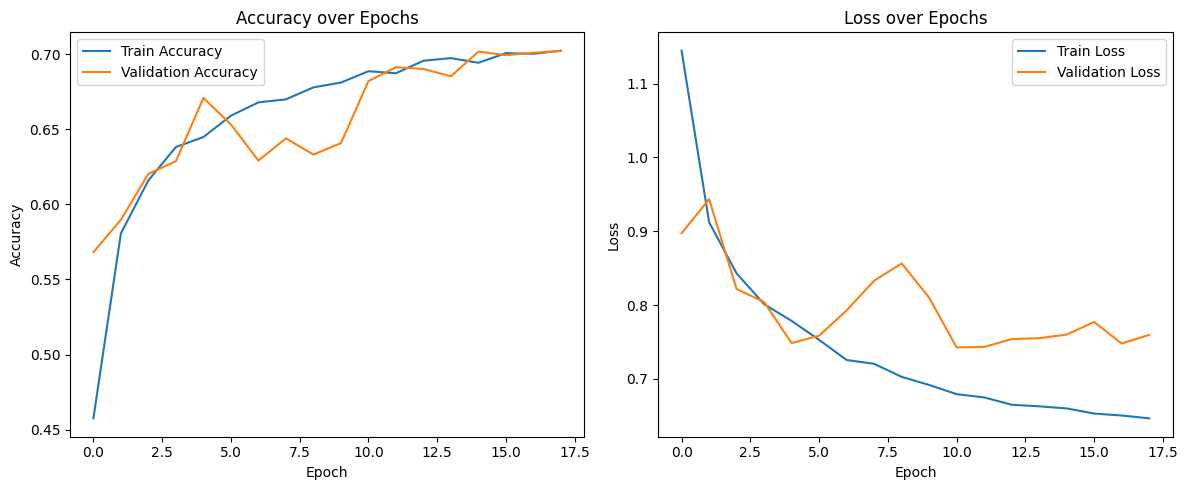

In [18]:
plot_training_history(history)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 512, 512, 3))
  warnings.warn(msg)


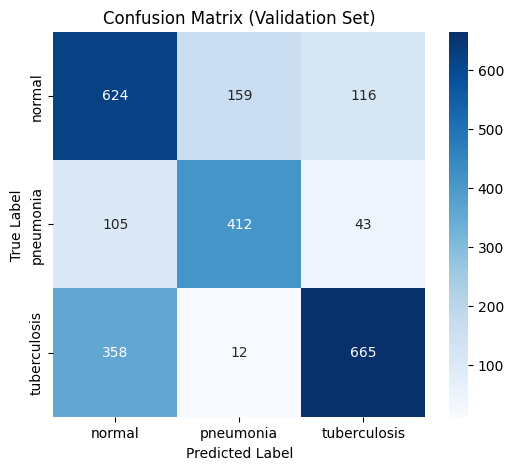


Classification Report:

              precision    recall  f1-score   support

      normal      0.574     0.694     0.628       899
   pneumonia      0.707     0.736     0.721       560
tuberculosis      0.807     0.643     0.715      1035

    accuracy                          0.682      2494
   macro avg      0.696     0.691     0.688      2494
weighted avg      0.701     0.682     0.685      2494



In [19]:
evaluate(model_weight_segmented, val_mask_ds, class_names)

In [25]:
# Save the full model as a single HDF5 file
full_model_h5 = os.path.join(working_dir, "model_weight_segmented.h5")
model_weight_segmented.save(full_model_h5)


In [28]:
weights_h5 = os.path.join(working_dir, "model_weights_segmented_wights.weights.h5")
model_weight_segmented.save_weights(weights_h5)

## CNN_3 Model Architecture

In [29]:
!pip install focal-loss

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import *

# --------------------------
# CBAM BLOCK 
# --------------------------
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    avg_pool = layers.Dense(channel // ratio, activation='relu')(avg_pool)
    max_pool = layers.Dense(channel // ratio, activation='relu')(max_pool)

    avg_pool = layers.Dense(channel, activation='sigmoid')(avg_pool)
    max_pool = layers.Dense(channel, activation='sigmoid')(max_pool)

    channel_attention = layers.Add()([avg_pool, max_pool])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention -----
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = layers.Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    spatial_refined = layers.Multiply()([channel_refined, spatial_attention])

    return spatial_refined


# --------------------------
#  MODEL ARCHITECTURE
# --------------------------
img_input_ = Input(shape=(512, 512, 3))
img_ = Resizing(224, 224)(img_input_)
img_ = BatchNormalization()(img_)

# ---- Convolution Block 1 ----
hidden = Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(img_)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Conv2D(32, 3,  padding='same',kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = cbam_block(hidden)
hidden = MaxPool2D()(hidden)

# ---- Convolution Block 2 ----
hidden = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = cbam_block(hidden)
#hidden = MaxPool2D()(hidden)

#---- Convolution Block 3 ----
# hidden = Conv2D(128, 3, padding='same', kernel_initializer='he_normal' , kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
# hidden = BatchNormalization()(hidden)
# hidden = ReLU()(hidden)
# hidden = Conv2D(128, 3, padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
# hidden = BatchNormalization()(hidden)
# hidden = ReLU()(hidden)
# hidden = cbam_block(hidden)

# ---- Global Pooling ----
hidden = GlobalAveragePooling2D()(hidden)

# ---- Dense Layers ----
hidden = Dense(64, kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Dropout(0.4)(hidden)

# ---- Output Layer ----
output = Dense(3, activation='softmax', kernel_initializer='glorot_normal')(hidden)

# ---- Model ----
model_cbam = Model(inputs=[img_input_], outputs=[output])

# ---- Summary ----
model_cbam.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         12 │ resizing_1[0][0]  │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 224, 224,  │        896 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │      9,248 │ re_lu_7[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_8[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ re_lu_8[0][0]     │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        132 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        160 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ dense_4[0][0],    │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 73,933 (288.80 KB)

 Trainable params: 73,415 (286.78 KB)

 Non-trainable params: 518 (2.02 KB)

In [181]:
# Compile
from focal_loss import SparseCategoricalFocalLoss

loss = SparseCategoricalFocalLoss(gamma=2, class_weight=[1.0,1.4, 0.7])

from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.00001) 
model_cbam.compile(optimizer=optimizer, loss= loss,
metrics=['accuracy'])

In [182]:
#Train the model
history = model_cbam.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 25,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    verbose=1
)

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1411']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


596/596 ━━━━━━━━━━━━━━━━━━━━ 74s 99ms/step - accuracy: 0.3935 - loss: 0.5731 - val_accuracy: 0.4872 - val_loss: 0.4165 - learning_rate: 1.0000e-05
Epoch 2/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 88ms/step - accuracy: 0.4897 - loss: 0.4260 - val_accuracy: 0.4856 - val_loss: 0.3733 - learning_rate: 1.0000e-05
Epoch 3/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 88ms/step - accuracy: 0.5358 - loss: 0.3662 - val_accuracy: 0.5040 - val_loss: 0.3690 - learning_rate: 1.0000e-05
Epoch 4/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 87ms/step - accuracy: 0.5631 - loss: 0.3374 - val_accuracy: 0.5156 - val_loss: 0.3438 - learning_rate: 1.0000e-05
Epoch 5/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 88ms/step - accuracy: 0.5760 - loss: 0.3185 - val_accuracy: 0.4904 - val_loss: 0.3664 - learning_rate: 1.0000e-05
Epoch 6/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 87ms/step - accuracy: 0.5866 - loss: 0.3056 - val_accuracy: 0.4683 - val_loss: 0.3890 - learning_rate: 1.0000e-05
Epoch 7/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 87ms/step - accurac

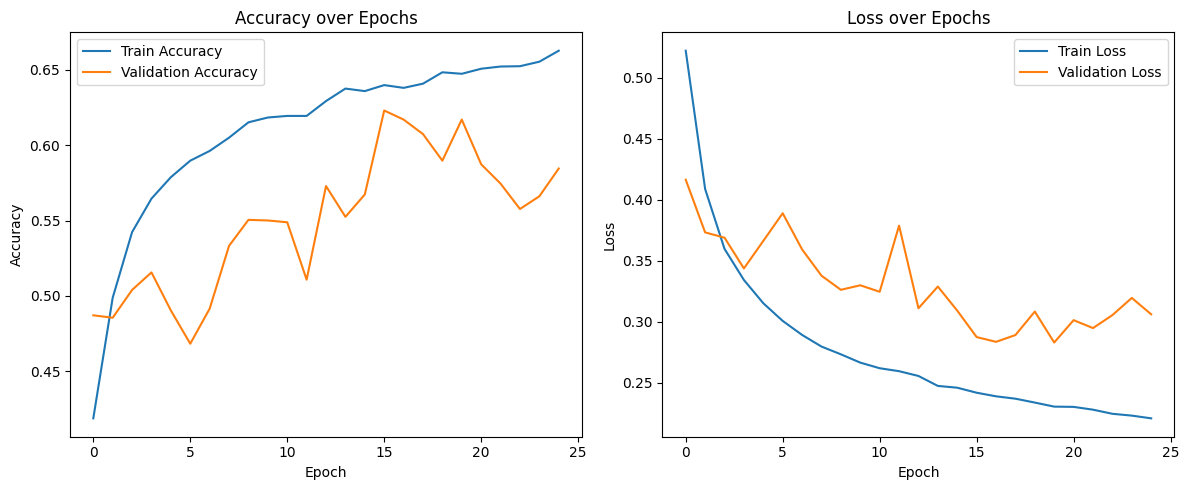

In [183]:
plot_training_history(history)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1411']
Received: inputs=Tensor(shape=(32, 512, 512, 3))
  warnings.warn(msg)


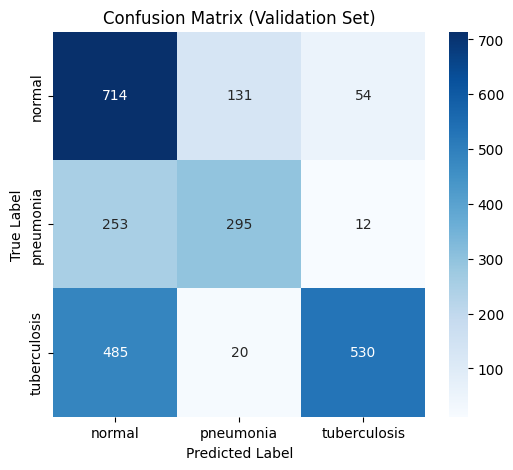


Classification Report:

              precision    recall  f1-score   support

      normal      0.492     0.794     0.607       899
   pneumonia      0.661     0.527     0.586       560
tuberculosis      0.889     0.512     0.650      1035

    accuracy                          0.617      2494
   macro avg      0.681     0.611     0.615      2494
weighted avg      0.695     0.617     0.620      2494



In [184]:
evaluate(model_cbam, val_mask_ds, class_names)

## CNN_4 Model Architecture

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import *

# --------------------------
# CBAM BLOCK 
# --------------------------
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    avg_pool = layers.Dense(channel // ratio, activation='relu')(avg_pool)
    max_pool = layers.Dense(channel // ratio, activation='relu')(max_pool)

    avg_pool = layers.Dense(channel, activation='sigmoid')(avg_pool)
    max_pool = layers.Dense(channel, activation='sigmoid')(max_pool)

    channel_attention = layers.Add()([avg_pool, max_pool])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention -----
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = layers.Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    spatial_refined = layers.Multiply()([channel_refined, spatial_attention])

    return spatial_refined


# --------------------------
#  MODEL ARCHITECTURE
# --------------------------
img_input_ = Input(shape=(512, 512, 3))
img_ = Resizing(224, 224)(img_input_)
img_ = BatchNormalization()(img_)

# ---- Convolution Block 1 ----
hidden = Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(img_)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Conv2D(32, 3,  padding='same',kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
# hidden = cbam_block(hidden)
hidden = MaxPool2D()(hidden)

# ---- Convolution Block 2 ----
hidden = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
#hidden = cbam_block(hidden)
hidden = MaxPool2D()(hidden)

# ---- Convolution Block 3 ----
hidden = Conv2D(128, 3, padding='same', kernel_initializer='he_normal' , kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Conv2D(128, 3, padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = cbam_block(hidden)

# ---- Global Pooling ----
hidden = GlobalAveragePooling2D()(hidden)

# ---- Dense Layers ----
hidden = Dense(128, kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Dropout(0.4)(hidden)

# ---- Output Layer ----
output = Dense(3, activation='softmax', kernel_initializer='glorot_normal')(hidden)

# ---- Model ----
model_cbam = Model(inputs=[img_input_], outputs=[output])

# ---- Summary ----
model_cbam.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_3          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         12 │ resizing_3[0][0]  │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 224, 224,  │        896 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 224, 224,  │      9,248 │ re_lu_19[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 112, 112,  │          0 │ re_lu_20[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 112, 112,  │     36,928 │ re_lu_21[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 56, 56,    │          0 │ re_lu_22[0][0]  

 Total params: 314,802 (1.20 MB)

 Trainable params: 313,644 (1.20 MB)

 Non-trainable params: 1,158 (4.52 KB)

In [37]:
# Compile
from focal_loss import SparseCategoricalFocalLoss

loss = SparseCategoricalFocalLoss(gamma=2, class_weight=[1.0,1.4, 0.8])

from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001) 
model_cbam.compile(optimizer=optimizer, loss= loss,
metrics=['accuracy'])

In [38]:
#Train the model
history = model_cbam.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 25,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    verbose=1
)

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_175']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


596/596 ━━━━━━━━━━━━━━━━━━━━ 72s 97ms/step - accuracy: 0.5446 - loss: 0.4770 - val_accuracy: 0.5489 - val_loss: 0.5029 - learning_rate: 1.0000e-04
Epoch 2/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 87ms/step - accuracy: 0.6664 - loss: 0.2881 - val_accuracy: 0.5946 - val_loss: 0.4051 - learning_rate: 1.0000e-04
Epoch 3/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 86ms/step - accuracy: 0.6951 - loss: 0.2507 - val_accuracy: 0.6644 - val_loss: 0.3488 - learning_rate: 1.0000e-04
Epoch 4/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.7102 - loss: 0.2362 - val_accuracy: 0.6540 - val_loss: 0.4175 - learning_rate: 1.0000e-04
Epoch 5/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 52s 86ms/step - accuracy: 0.7170 - loss: 0.2210 - val_accuracy: 0.5726 - val_loss: 1.5755 - learning_rate: 1.0000e-04
Epoch 6/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.7246 - loss: 0.2096 - val_accuracy: 0.6576 - val_loss: 0.3834 - learning_rate: 1.0000e-04
Epoch 7/25
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accurac

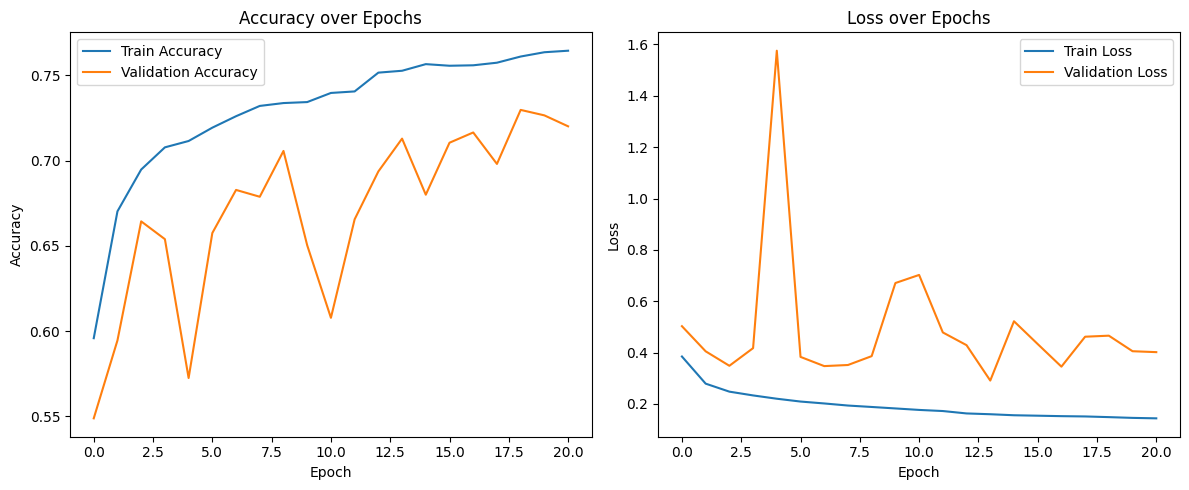

In [39]:
plot_training_history(history)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_175']
Received: inputs=Tensor(shape=(32, 512, 512, 3))
  warnings.warn(msg)


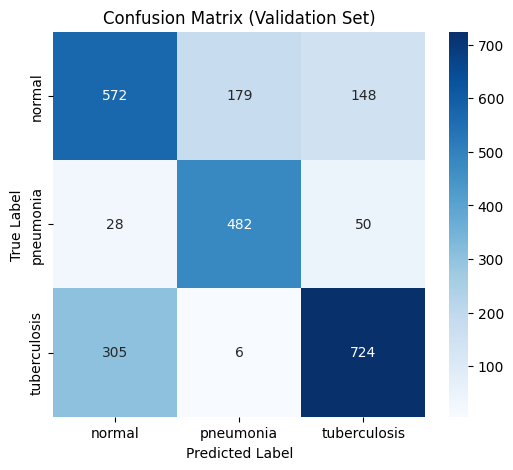


Classification Report:

              precision    recall  f1-score   support

      normal      0.632     0.636     0.634       899
   pneumonia      0.723     0.861     0.786       560
tuberculosis      0.785     0.700     0.740      1035

    accuracy                          0.713      2494
   macro avg      0.713     0.732     0.720      2494
weighted avg      0.716     0.713     0.712      2494



In [40]:
evaluate(model_cbam, val_mask_ds, class_names)

## Apply Grad_CAM on CNN_4

Found 10 normal and 10 TB images
Using last conv layer: conv2d_27


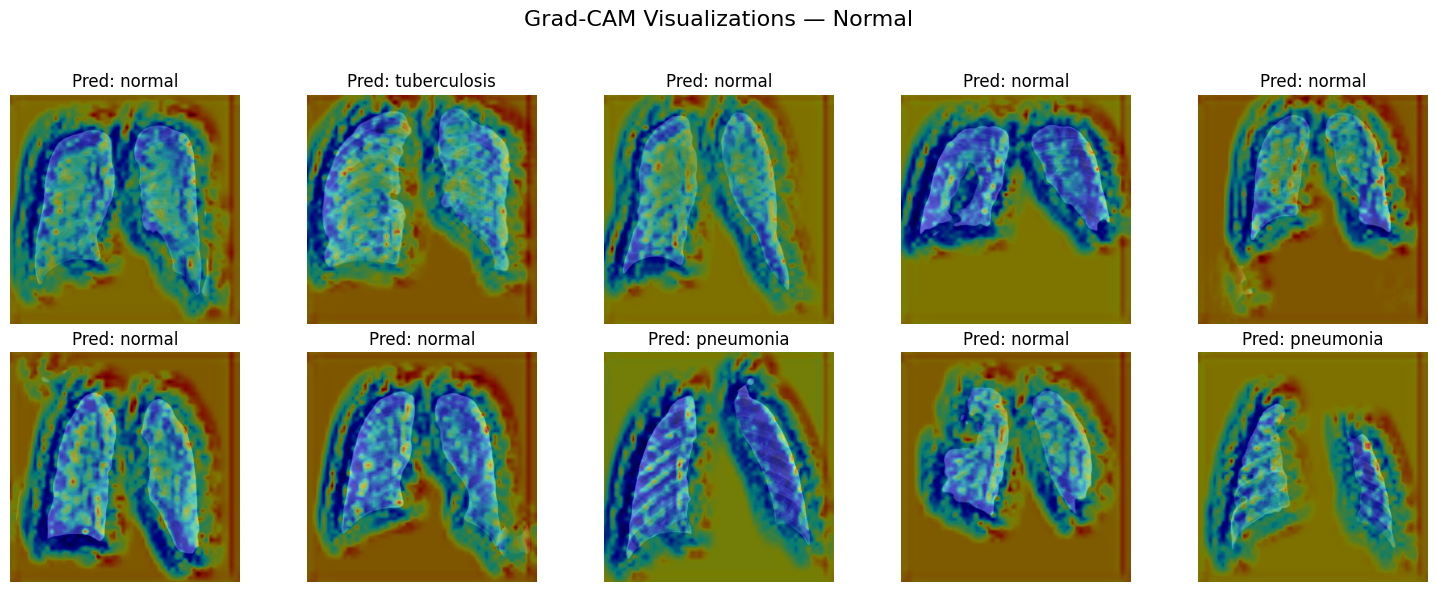

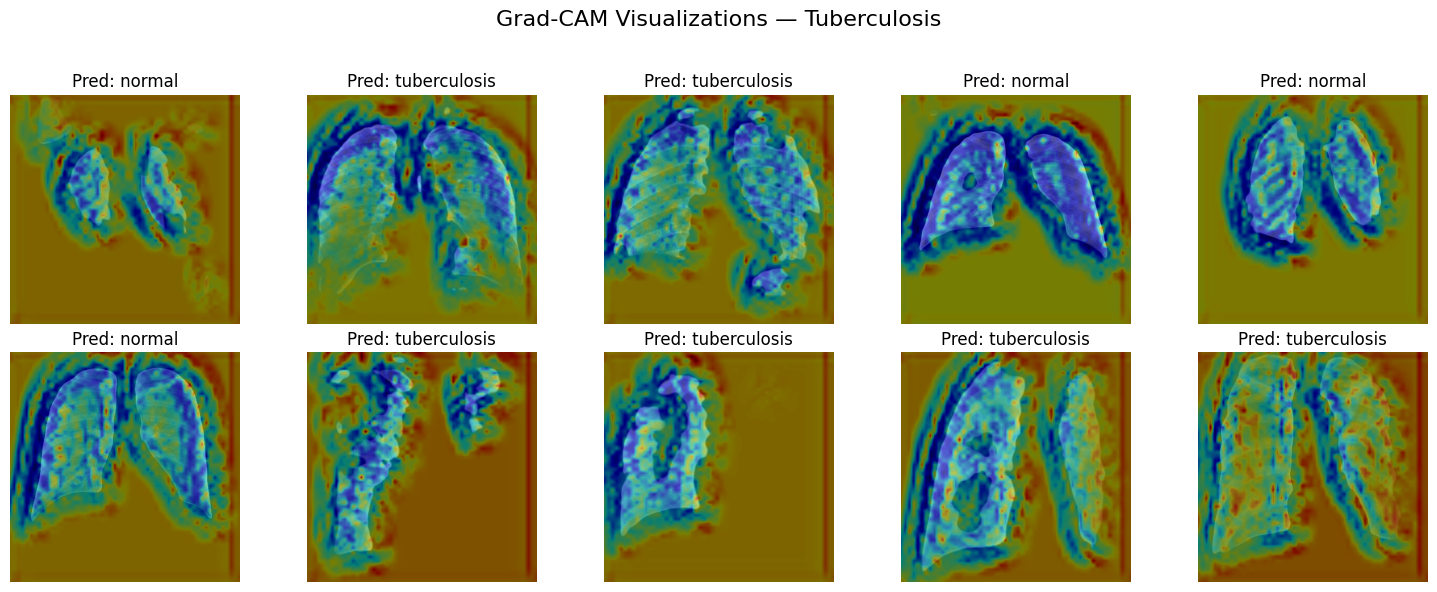

In [84]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

# ---------------------------
# Prepare a few validation images
# ---------------------------
class_names = val_mask_ds.class_names  # list of your classes

normal_imgs, tb_imgs = [], []

# Take 10 images per class
for img, label in val_mask_ds.unbatch():
    lbl = int(label.numpy())
    if lbl == class_names.index('normal') and len(normal_imgs) < 10:
        normal_imgs.append(img)
    elif lbl == class_names.index('tuberculosis') and len(tb_imgs) < 10:
        tb_imgs.append(img)
    if len(normal_imgs) == 10 and len(tb_imgs) == 10:
        break

print(f"Found {len(normal_imgs)} normal and {len(tb_imgs)} TB images")

# Convert to tensor
normal_tensor = tf.stack(normal_imgs)
tb_tensor = tf.stack(tb_imgs)
images = tf.concat([normal_tensor, tb_tensor], axis=0)

# ---------------------------
# Setup Grad-CAM
# ---------------------------
modifier = ReplaceToLinear()
gradcam = Gradcam(model_cbam, model_modifier=modifier, clone=False)

# Find last conv layer automatically
last_conv_layer_name = [layer.name for layer in model_cbam.layers if 'conv' in layer.name][-1]
print(f"Using last conv layer: {last_conv_layer_name}")

# ---------------------------
# Generate Grad-CAMs
# ---------------------------
cams = []
pred_labels = []

for img in images:
    img_batch = tf.expand_dims(img, axis=0)
    preds = model_cbam.predict(img_batch, verbose=0)
    pred_class = tf.argmax(preds[0]).numpy()
    pred_labels.append(class_names[pred_class])

    score = CategoricalScore([pred_class])
    cam = gradcam(score, img_batch, penultimate_layer=last_conv_layer_name)
    cams.append(cam[0])

# ---------------------------
# Plot Grad-CAM results
# ---------------------------
def plot_grid(imgs, cams, labels, class_title):
    plt.figure(figsize=(15, 6))
    plt.suptitle(f"Grad-CAM Visualizations — {class_title}", fontsize=16)
    for i in range(len(imgs)):
        plt.subplot(2, 5, i+1)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.imshow(cams[i], cmap='jet', alpha=0.5)
        plt.title(f"Pred: {labels[i]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_grid(normal_imgs, cams[:10], pred_labels[:10], "Normal")
plot_grid(tb_imgs, cams[10:], pred_labels[10:], "Tuberculosis")


In [41]:
# Save the full model as a single HDF5 file
full_model_h5 = os.path.join(working_dir, "model_cbam_last.h5")
model_cbam.save(full_model_h5)

In [42]:
weights_h5 = os.path.join(working_dir, "model_cbam_last.weights.h5")
model_cbam.save_weights(weights_h5)

## EfficientNetB0 Transfer Learning 

In [185]:
from IPython.display import Image, display

# DenseNet121 Architecture
url = "https://www.researchgate.net/profile/Tashin-Ahmed/publication/344410350/figure/fig4/AS:1022373302128641@1620764198841/Architecture-of-EfficientNet-B0-with-MBConv-as-Basic-building-blocks.png"
display(Image(url=url, width=800))


In [131]:
from tensorflow.keras.applications import EfficientNetB0, efficientnet
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, Lambda, 
    RandomFlip, RandomRotation, RandomZoom, Resizing
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Input
input_ = Input(shape=(512, 512, 3))
x_ray_ = Resizing(224, 224)(input_)

# Data augmentation
x_ray_ = RandomFlip("horizontal")(x_ray_)
x_ray_ = RandomRotation(0.1)(x_ray_)
x_ray_ = RandomZoom(0.1)(x_ray_)

# Preprocessing
x_ray_ = Lambda(efficientnet.preprocess_input)(x_ray_)

# Base model
base_model = EfficientNetB0(weights='imagenet', include_top=False)
base_model.trainable = False
x_ray_ = base_model(x_ray_, training=False)

# Classification head
x_ray_ = GlobalAveragePooling2D()(x_ray_)
x_ray_ = Dropout(0.3)(x_ray_)
x_ray_ = Dense(128, activation='relu')(x_ray_)
output = Dense(3, activation='softmax')(x_ray_)

# Build model
model_EfficientNetB0 = Model(inputs=input_, outputs=output)

model_EfficientNetB0.summary()


Model: "functional_129"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_9 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_18 (Lambda)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_19     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [87]:
# Compile
model_EfficientNetB0.compile(optimizer=Adam(learning_rate=1e-5),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

In [88]:
# Train the model
history = model_EfficientNetB0.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 15,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    class_weight = class_weights,              # keep my class weights
    verbose=1
)

Epoch 1/15


E0000 00:00:1762033849.654356      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_127_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


596/596 ━━━━━━━━━━━━━━━━━━━━ 59s 73ms/step - accuracy: 0.4141 - loss: 1.0800 - val_accuracy: 0.5718 - val_loss: 0.8965 - learning_rate: 1.0000e-05
Epoch 2/15
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5444 - loss: 0.9098 - val_accuracy: 0.5778 - val_loss: 0.8456 - learning_rate: 1.0000e-05
Epoch 3/15
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5887 - loss: 0.8340 - val_accuracy: 0.5770 - val_loss: 0.8354 - learning_rate: 1.0000e-05
Epoch 4/15
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.6035 - loss: 0.7998 - val_accuracy: 0.5746 - val_loss: 0.8392 - learning_rate: 1.0000e-05
Epoch 5/15
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.6147 - loss: 0.7776 - val_accuracy: 0.5838 - val_loss: 0.8278 - learning_rate: 1.0000e-05
Epoch 6/15
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.6220 - loss: 0.7628 - val_accuracy: 0.5870 - val_loss: 0.8198 - learning_rate: 1.0000e-05
Epoch 7/15
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accurac

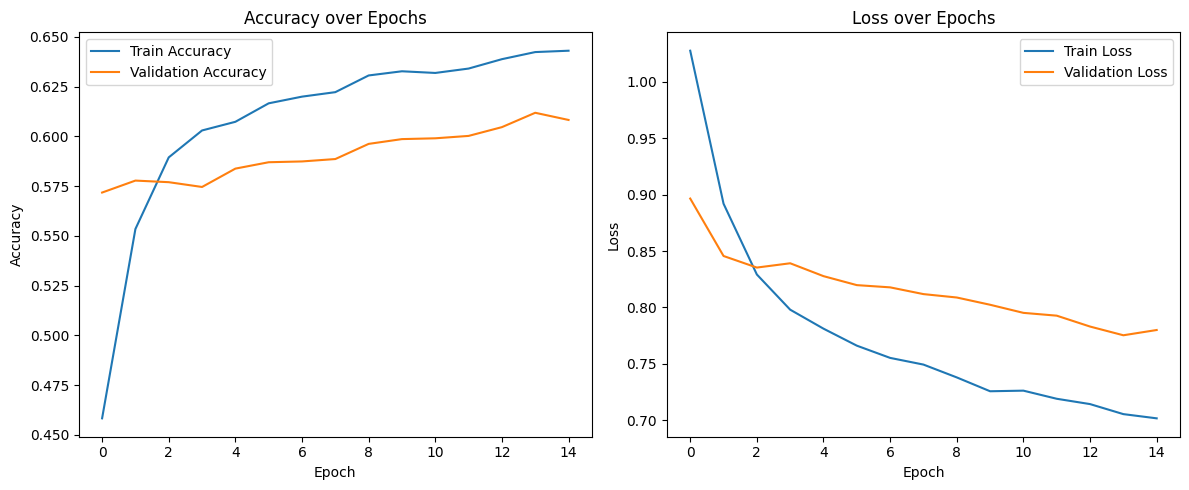

In [89]:
plot_training_history(history)

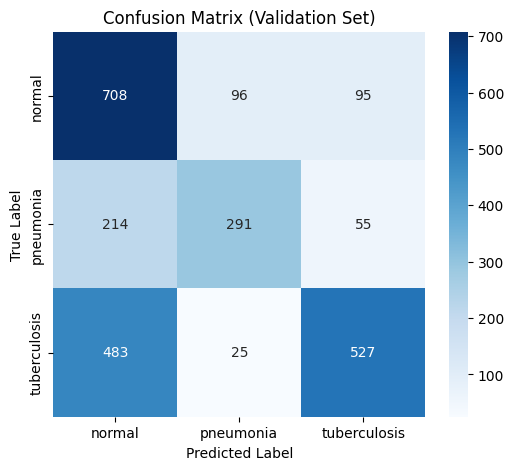


Classification Report:

              precision    recall  f1-score   support

      normal      0.504     0.788     0.615       899
   pneumonia      0.706     0.520     0.599       560
tuberculosis      0.778     0.509     0.616      1035

    accuracy                          0.612      2494
   macro avg      0.663     0.605     0.610      2494
weighted avg      0.663     0.612     0.611      2494



In [90]:
evaluate(model_EfficientNetB0 , val_mask_ds , class_names)

## Fine-Tuning of EfficientNetB0 Model

In [107]:
# Fine-tune last 40 layers
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Compile
model_EfficientNetB0.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [108]:
# Train the model
history = model_EfficientNetB0.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 20,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    class_weight = class_weights,             # keep my class weights
    verbose=1
)

Epoch 1/20


E0000 00:00:1762035808.731535      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_128_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


596/596 ━━━━━━━━━━━━━━━━━━━━ 72s 84ms/step - accuracy: 0.4911 - loss: 0.9936 - val_accuracy: 0.5966 - val_loss: 0.8050 - learning_rate: 1.0000e-05
Epoch 2/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - accuracy: 0.6369 - loss: 0.7475 - val_accuracy: 0.6223 - val_loss: 0.7404 - learning_rate: 1.0000e-05
Epoch 3/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - accuracy: 0.6581 - loss: 0.6769 - val_accuracy: 0.6508 - val_loss: 0.6964 - learning_rate: 1.0000e-05
Epoch 4/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - accuracy: 0.6742 - loss: 0.6392 - val_accuracy: 0.6600 - val_loss: 0.6717 - learning_rate: 1.0000e-05
Epoch 5/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - accuracy: 0.6807 - loss: 0.6130 - val_accuracy: 0.6688 - val_loss: 0.6508 - learning_rate: 1.0000e-05
Epoch 6/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - accuracy: 0.6845 - loss: 0.5988 - val_accuracy: 0.6768 - val_loss: 0.6400 - learning_rate: 1.0000e-05
Epoch 7/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accurac

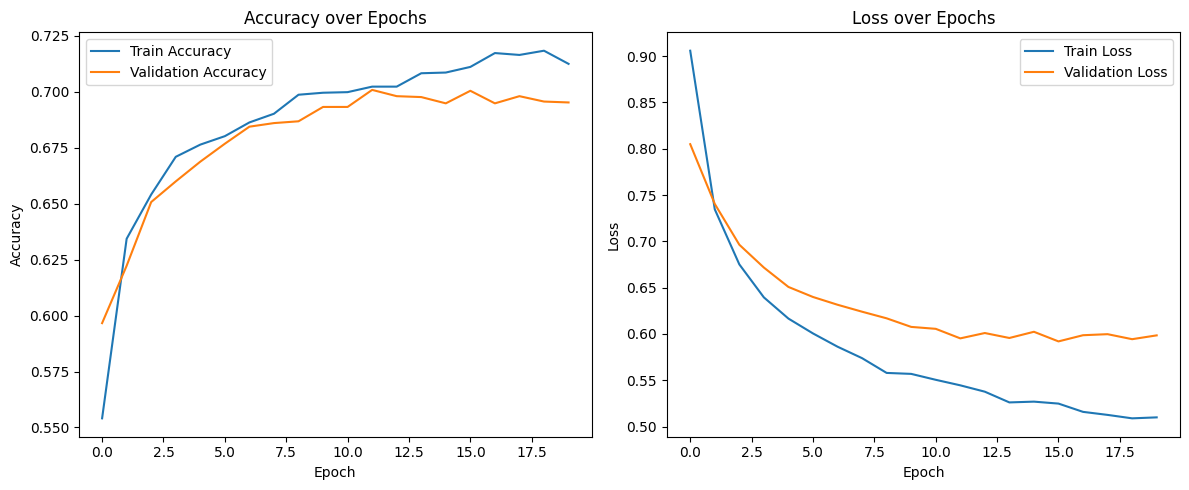

In [109]:
plot_training_history(history)

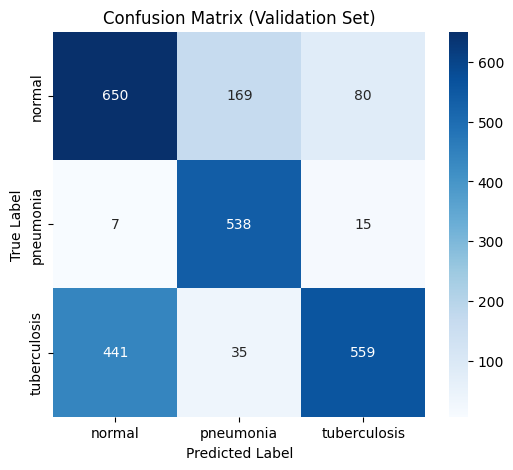


Classification Report:

              precision    recall  f1-score   support

      normal      0.592     0.723     0.651       899
   pneumonia      0.725     0.961     0.826       560
tuberculosis      0.855     0.540     0.662      1035

    accuracy                          0.700      2494
   macro avg      0.724     0.741     0.713      2494
weighted avg      0.731     0.700     0.695      2494



In [110]:
evaluate(model_EfficientNetB0 , val_mask_ds , class_names)

## Fine-Tuning of EfficientNetB0 unfreeze more layers

In [132]:
# Fine-tune last more layers
for layer in base_model.layers[-60:]:
    layer.trainable = True
    
model_EfficientNetB0.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [133]:
history = model_EfficientNetB0.fit(
    train_mask_ds,
    validation_data=val_mask_ds,
    epochs=20,
    callbacks=[early_stop, ReduceLrOnPlat],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20


E0000 00:00:1762039060.936554      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_129_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


596/596 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.4995 - loss: 0.9861 - val_accuracy: 0.5914 - val_loss: 0.8052 - learning_rate: 1.0000e-05
Epoch 2/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6443 - loss: 0.7306 - val_accuracy: 0.6395 - val_loss: 0.7271 - learning_rate: 1.0000e-05
Epoch 3/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6671 - loss: 0.6595 - val_accuracy: 0.6752 - val_loss: 0.6804 - learning_rate: 1.0000e-05
Epoch 4/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6801 - loss: 0.6200 - val_accuracy: 0.6832 - val_loss: 0.6574 - learning_rate: 1.0000e-05
Epoch 5/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6882 - loss: 0.5960 - val_accuracy: 0.6893 - val_loss: 0.6360 - learning_rate: 1.0000e-05
Epoch 6/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.6882 - loss: 0.5810 - val_accuracy: 0.6957 - val_loss: 0.6265 - learning_rate: 1.0000e-05
Epoch 7/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accurac

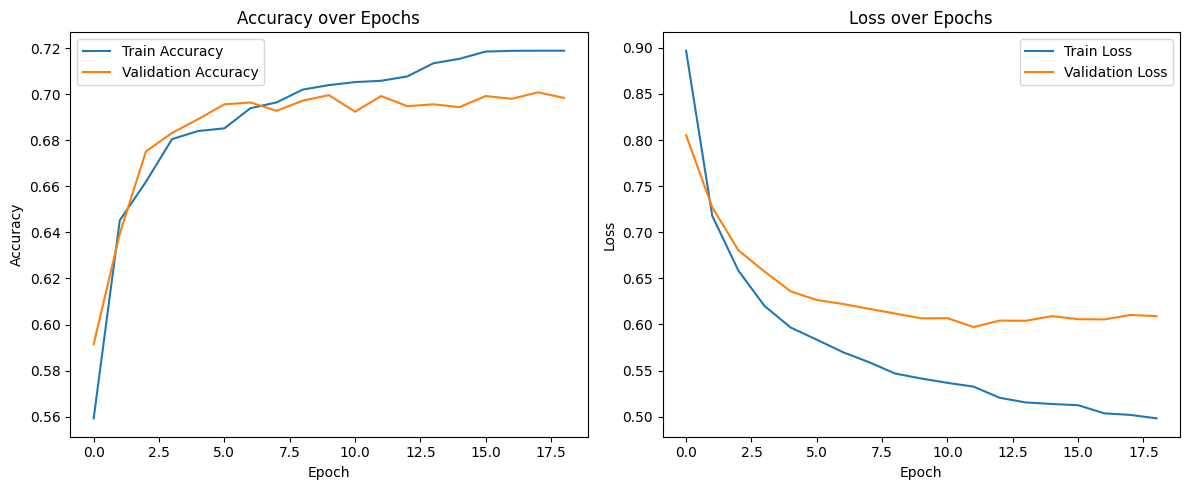

In [134]:
plot_training_history(history)

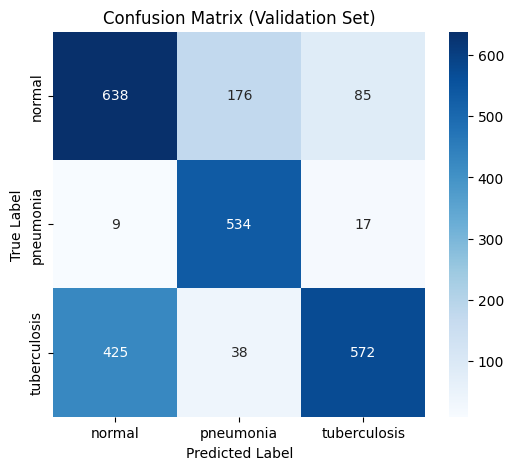


Classification Report:

              precision    recall  f1-score   support

      normal      0.595     0.710     0.647       899
   pneumonia      0.714     0.954     0.817       560
tuberculosis      0.849     0.553     0.669      1035

    accuracy                          0.699      2494
   macro avg      0.719     0.739     0.711      2494
weighted avg      0.727     0.699     0.694      2494



In [135]:
evaluate(model_EfficientNetB0 , val_mask_ds , class_names)

In [ ]:
model_EfficientNetB0.save("/kaggle/working/main_model")


In [ ]:
model_EfficientNetB0.save_weights("/kaggle/working/model_weights.h5")


## EfficientNet B0 + ECA

In [30]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, Conv1D, Multiply

def eca_block(inputs, k_size=3):
    channels = inputs.shape[-1]
    
    # Global average pooling
    x = GlobalAveragePooling2D()(inputs)           # shape: (batch, channels)
    x = Reshape((channels, 1))(x)                  # shape: (batch, channels, 1)
    
    # 1D convolution across channels (k_size kernel)
    x = Conv1D(1, kernel_size=k_size, padding='same', activation='sigmoid', use_bias=False)(x)
    
    x = Reshape((1, 1, channels))(x)              # reshape to multiply
    out = Multiply()([inputs, x])                 # scale input channels
    
    return out


In [31]:
from tensorflow.keras.applications import EfficientNetB0, efficientnet
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, Lambda, 
    RandomFlip, RandomRotation, RandomZoom, Resizing, Multiply, Conv1D, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# ----- Input and preprocessing -----
input_ = Input(shape=(512, 512, 3))
x = Resizing(224, 224)(input_)

# Data augmentation
x = RandomFlip("horizontal")(x)
x = RandomRotation(0.1)(x)
x = RandomZoom(0.1)(x)

# Preprocessing
x = Lambda(efficientnet.preprocess_input)(x)

# ----- Base model -----
base_model = EfficientNetB0(weights='imagenet', include_top=False)
base_model.trainable = False  # Freeze base model initially
x = base_model(x, training=False)

# ----- Add ECA attention -----
x = eca_block(x, k_size=3)

# ----- Classification head -----
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

# ----- Build model -----
model_EfficientNetB0_eac = Model(inputs=input_, outputs=output)

# ----- Summary -----
model_EfficientNetB0_eac.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_2          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ resizing_2[0][0]  │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ lambda_4[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1280, 1)   │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1280, 1)   │          3 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1,      │          0 │ conv1d[0][0]      │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│ (Multiply)          │ 1280)             │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_4[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │    163,968 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 3)         │        387 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,213,929 (16.07 MB)

 Trainable params: 164,358 (642.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [32]:
# Compile
model_EfficientNetB0_eac.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [202]:
# Train the model
history = model_EfficientNetB0_eac.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 20,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    class_weight = class_weights,             # keep my class weights
    verbose=1
)

Epoch 1/20


E0000 00:00:1762043570.235355      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_135_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


596/596 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.4225 - loss: 1.0785 - val_accuracy: 0.4623 - val_loss: 0.9830 - learning_rate: 1.0000e-05
Epoch 2/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.5724 - loss: 0.9550 - val_accuracy: 0.4876 - val_loss: 0.9376 - learning_rate: 1.0000e-05
Epoch 3/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.5989 - loss: 0.8809 - val_accuracy: 0.5068 - val_loss: 0.9137 - learning_rate: 1.0000e-05
Epoch 4/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.6067 - loss: 0.8324 - val_accuracy: 0.5209 - val_loss: 0.9050 - learning_rate: 1.0000e-05
Epoch 5/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.6215 - loss: 0.8036 - val_accuracy: 0.5329 - val_loss: 0.8945 - learning_rate: 1.0000e-05
Epoch 6/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.6250 - loss: 0.7792 - val_accuracy: 0.5425 - val_loss: 0.8880 - learning_rate: 1.0000e-05
Epoch 7/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accurac

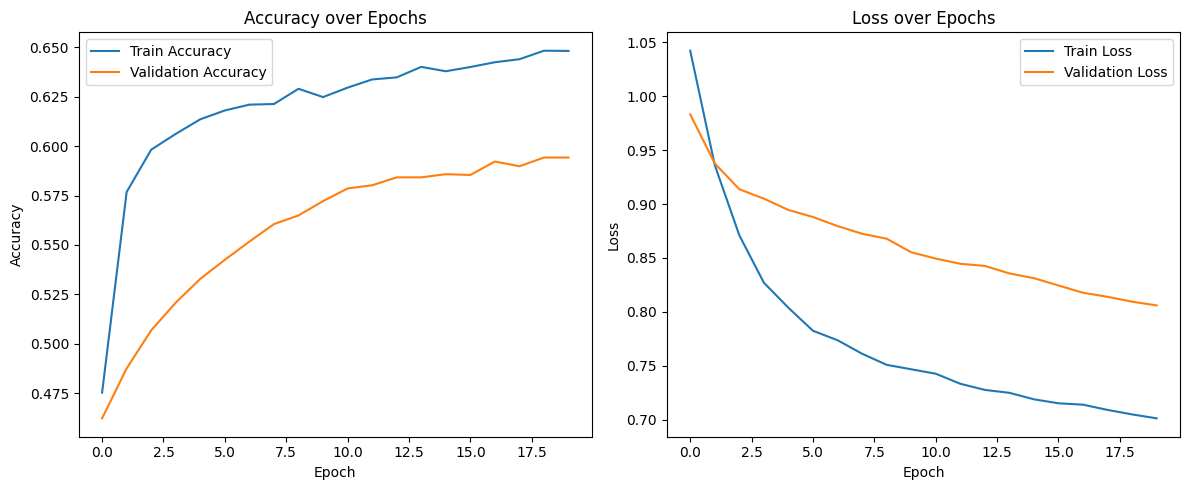

In [203]:
plot_training_history(history)

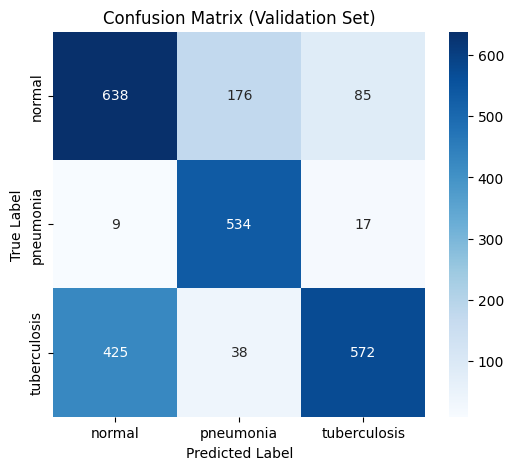


Classification Report:

              precision    recall  f1-score   support

      normal      0.595     0.710     0.647       899
   pneumonia      0.714     0.954     0.817       560
tuberculosis      0.849     0.553     0.669      1035

    accuracy                          0.699      2494
   macro avg      0.719     0.739     0.711      2494
weighted avg      0.727     0.699     0.694      2494



In [204]:
evaluate(model_EfficientNetB0 , val_mask_ds , class_names)

## Fine Tune EfficientNetB0 + EAC

In [34]:
# Fine-tune last 40 layers
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Compile
model_EfficientNetB0_eac.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_EfficientNetB0_eac.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_2          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ resizing_2[0][0]  │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ lambda_4[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1280, 1)   │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1280, 1)   │          3 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1,      │          0 │ conv1d[0][0]      │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│ (Multiply)          │ 1280)             │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_4[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │    163,968 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 3)         │        387 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,213,929 (16.07 MB)

 Trainable params: 2,215,062 (8.45 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [ ]:
# Train the model
history = model_EfficientNetB0_eac.fit(
    train_mask_ds,
    validation_data = val_mask_ds,
    epochs = 20,
    callbacks=[early_stop, ReduceLrOnPlat],  # keep my callbacks
    class_weight = class_weights,             # keep my class weights
    verbose=1
)

Epoch 1/20


E0000 00:00:1762052543.832538      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1762052547.337361     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


596/596 ━━━━━━━━━━━━━━━━━━━━ 79s 89ms/step - accuracy: 0.4495 - loss: 1.0298 - val_accuracy: 0.6043 - val_loss: 0.8559 - learning_rate: 1.0000e-05
Epoch 2/20
596/596 ━━━━━━━━━━━━━━━━━━━━ 46s 77ms/step - accuracy: 0.6315 - loss: 0.7791 - val_accuracy: 0.6480 - val_loss: 0.7477 - learning_rate: 1.0000e-05
Epoch 3/20
303/596 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.6676 - loss: 0.6818

In [ ]:
plot_training_history(history)

In [ ]:
evaluate(model_EfficientNetB0, val_mask_ds, class_names)

## Performance On Test Data

In [43]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tqdm import tqdm
from tensorflow.keras import layers, models

# --------------------------
# DEFINE U-NET MODEL
# --------------------------
def unet_small(input_size=(512, 512, 1)):  # Grayscale input
    inputs = layers.Input(input_size)

    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)

    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c9)
    model = models.Model(inputs, outputs)
    return model

# --------------------------
# LOAD SEGMENTATION MODEL
# --------------------------
seg_model = unet_small()
seg_model.load_weights("/kaggle/input/seg-model/tensorflow2/default/1/cxr_reg_weights.best.hdf5")
print("Lung segmentation U-Net loaded successfully!")

# --------------------------
# PATHS
# --------------------------
test_dir = "/kaggle/input/chest-xray-dataset/test"
masked_output_dir = "/kaggle/working/masked-test"
os.makedirs(masked_output_dir, exist_ok=True)
for cls in os.listdir(test_dir):
    os.makedirs(os.path.join(masked_output_dir, cls), exist_ok=True)

# --------------------------
# SEGMENT TEST IMAGES
# --------------------------
IMG_SIZE = (512, 512)

for cls in os.listdir(test_dir):
    input_cls_dir = os.path.join(test_dir, cls)
    output_cls_dir = os.path.join(masked_output_dir, cls)

    for filename in tqdm(os.listdir(input_cls_dir), desc=f"Segmenting {cls}"):
        img_path = os.path.join(input_cls_dir, filename)

        # Read as grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        img_array = img.astype(np.float32) / 255.0
        img_array = np.expand_dims(img_array, axis=-1)  # shape (512, 512, 1)
        img_input = np.expand_dims(img_array, axis=0)   # shape (1, 512, 512, 1)

        # Predict mask
        mask = seg_model.predict(img_input, verbose=0)[0]
        mask = (mask > 0.5).astype(np.uint8)

        # Apply mask
        masked_img = img_array * mask

        # Save masked image
        masked_img_uint8 = (masked_img * 255).astype(np.uint8)
        cv2.imwrite(os.path.join(output_cls_dir, filename), masked_img_uint8)

print("All test images segmented and saved in:", masked_output_dir)


Lung segmentation U-Net loaded successfully!


Segmenting normal: 100%|██████████| 925/925 [01:32<00:00, 10.00it/s]

All test images segmented and saved in: /kaggle/working/masked-test


In [49]:
# Create ZIP file for download
import zipfile  
from pathlib import Path
zip_path = "/kaggle/working/masked-test.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(masked_output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, masked_output_dir)
            zipf.write(file_path, arcname)

print(f"Masked dataset zipped and saved at: {zip_path}")

Masked dataset zipped and saved at: /kaggle/working/masked-test.zip


In [44]:
test_ds = tf.keras.utils.image_dataset_from_directory(   ## get my test data
    '/kaggle/working/masked-test',
    image_size = (512,512),
    batch_size = 32 ,
    labels ='inferred',
    color_mode ='rgb',
    shuffle = False,
    label_mode ="int"
)

Found 2569 files belonging to 3 classes.


In [45]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import *

# --------------------------
# CBAM BLOCK 
# --------------------------
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = GlobalMaxPooling2D()(input_feature)

    avg_pool = Dense(channel // ratio, activation='relu')(avg_pool)
    max_pool = Dense(channel // ratio, activation='relu')(max_pool)

    avg_pool = Dense(channel, activation='sigmoid')(avg_pool)
    max_pool = Dense(channel, activation='sigmoid')(max_pool)

    channel_attention = Add()([avg_pool, max_pool])
    channel_attention = Activation('sigmoid')(channel_attention)
    channel_attention = Reshape((1, 1, channel))(channel_attention)
    channel_refined = Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention -----
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    spatial_refined = Multiply()([channel_refined, spatial_attention])

    return spatial_refined


# --------------------------
#  MODEL ARCHITECTURE
# --------------------------
def build_cbam_model():
    img_input_ = Input(shape=(512, 512, 3))
    img_ = Resizing(224, 224)(img_input_)
    img_ = BatchNormalization()(img_)

    # ---- Convolution Block 1 ----
    hidden = Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(img_)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = MaxPool2D()(hidden)

    # ---- Convolution Block 2 ----
    hidden = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = MaxPool2D()(hidden)

    # ---- Convolution Block 3 ----
    hidden = Conv2D(128, 3, padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = Conv2D(128, 3, padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = cbam_block(hidden)

    # ---- Global Pooling ----
    hidden = GlobalAveragePooling2D()(hidden)

    # ---- Dense Layers ----
    hidden = Dense(128, kernel_initializer='he_normal')(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = ReLU()(hidden)
    hidden = Dropout(0.4)(hidden)

    # ---- Output Layer ----
    output = Dense(3, activation='softmax', kernel_initializer='glorot_normal')(hidden)

    model_cbam = Model(inputs=[img_input_], outputs=[output])
    return model_cbam


# --------------------------
#  LOAD WEIGHTS
# --------------------------
model_cbam = build_cbam_model()  
model_cbam.load_weights("/kaggle/input/model-weights/tensorflow1/default/1/model_cbam_last.weights.h5")
print("Model built and weights loaded successfully!")

model_cbam.summary()


Model built and weights loaded successfully!


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_3          │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         12 │ resizing_3[0][0]  │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 224, 224,  │        896 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_90[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 224, 224,  │      9,248 │ re_lu_14[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_91[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 112, 112,  │          0 │ re_lu_15[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_92[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 112, 112,  │     36,928 │ re_lu_16[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_93[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 56, 56,    │          0 │ re_lu_17[0][0]  

 Total params: 314,802 (1.20 MB)

 Trainable params: 313,644 (1.20 MB)

 Non-trainable params: 1,158 (4.52 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_716']
Received: inputs=Tensor(shape=(32, 512, 512, 3))
  warnings.warn(msg)


80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_716']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step
Test Accuracy: 62.94%

Classification Report:
              precision    recall  f1-score   support

      normal       0.57      0.58      0.57       925
   pneumonia       0.68      0.55      0.61       580
tuberculosis       0.66      0.72      0.69      1064

    accuracy                           0.63      2569
   macro avg       0.64      0.61      0.62      2569
weighted avg       0.63      0.63      0.63      2569



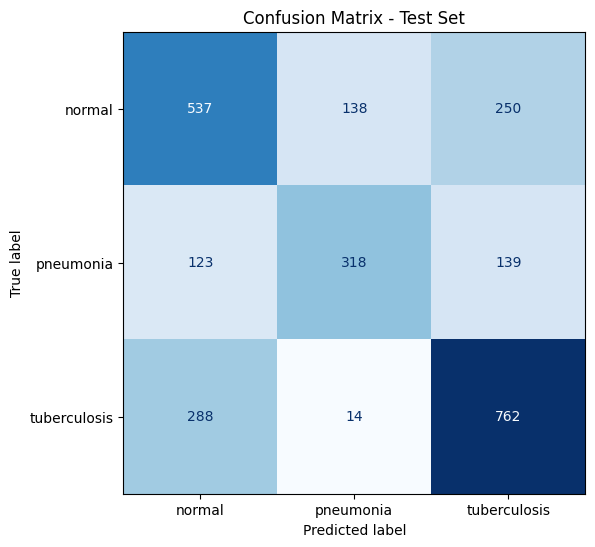

In [46]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --------------------------
# Predictions
# --------------------------
preds = model_cbam.predict(test_ds)
y_test_preds = tf.argmax(preds, axis=1).numpy()

# --------------------------
# True labels
# --------------------------
y_test_true = tf.concat([y for x, y in test_ds], axis=0).numpy()

# --------------------------
# Accuracy
# --------------------------
test_accuracy = accuracy_score(y_test_true, y_test_preds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# --------------------------
# Classification Report
# --------------------------
print("\nClassification Report:")
print(classification_report(y_test_true, y_test_preds, target_names=['normal', 'pneumonia', 'tuberculosis']))

# --------------------------
# Confusion Matrix
# --------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_true,
    y_test_preds,
    display_labels=['normal', 'pneumonia', 'tuberculosis'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
plt.title("Confusion Matrix - Test Set")
plt.show()
